## Imports

In [1]:
import pandas as pd
import pandas_gbq
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr, spearmanr
import matplotlib.ticker as ticker


## SQL-запит для створення датасету згідно з ТЗ

In [2]:
# SQL-запит для створення датасету згідно з ТЗ
sql_query = """
SELECT
    s.date AS order_date,
    s.ga_session_id,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.medium AS traffic_source,
    sp.channel,
    a.id AS registered_user_id,
    a.is_verified AS email_confirmed,
    a.is_unsubscribed AS unsubscribed,
    p.category,
    p.name AS product_name,
    p.price,
    p.short_description
FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
    ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.order` o
    ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
    ON o.item_id = p.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
    ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
    ON acs.account_id = a.id
"""

# Виконання запиту та завантаження даних у DataFrame
df = pandas_gbq.read_gbq(
    sql_query,
    project_id='data-analytics-mate'
)

Downloading: 100%|██████████|


## Перевірка структури та якості даних

In [3]:
print("Розмір датафрейму:", df.shape)
print("\nІнформація про колонки:")
df.info()

print("\nПерші 5 рядків:")
df.head()

print("\nПеревірка пропусків:")
df.isnull().sum()

Розмір датафрейму: (349545, 18)

Інформація про колонки:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_date          349545 non-null  dbdate 
 1   ga_session_id       349545 non-null  Int64  
 2   continent           349545 non-null  object 
 3   country             349545 non-null  object 
 4   device              349545 non-null  object 
 5   browser             349545 non-null  object 
 6   mobile_model_name   349545 non-null  object 
 7   operating_system    349545 non-null  object 
 8   language            235279 non-null  object 
 9   traffic_source      349545 non-null  object 
 10  channel             349545 non-null  object 
 11  registered_user_id  27945 non-null   Int64  
 12  email_confirmed     27945 non-null   Int64  
 13  unsubscribed        27945 non-null   Int64  
 14  category            33538 n

,0
order_date,0
ga_session_id,0
continent,0
country,0
device,0
browser,0
mobile_model_name,0
operating_system,0
language,114266
traffic_source,0


## Опис датасета по ТЗ

In [4]:
# 1. Кількість колонок числового типу
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'Int64']).columns
print("Числові колонки:", list(numeric_cols))
print("Кількість:", len(numeric_cols))

# 2. Кількість категоріальних колонок (object)
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nКатегоріальні колонки:", list(categorical_cols))
print("Кількість:", len(categorical_cols))

# 3. Кількість datetime колонок
datetime_cols = df.select_dtypes(include=['datetime64', 'dbdate']).columns
print("\nDatetime колонки:", list(datetime_cols))
print("Кількість:", len(datetime_cols))

# 4. Унікальні сесії
print("\nУнікальних сесій:", df['ga_session_id'].nunique())

# 5. Період часу
print("Період:", df['order_date'].min(), "до", df['order_date'].max())

# 6. Колонки з більш ніж 30% пропусків
print("\nКолонки з >30% пропусків:")
null_percent = df.isnull().sum() / len(df) * 100
print(null_percent[null_percent > 30])

Числові колонки: ['ga_session_id', 'registered_user_id', 'email_confirmed', 'unsubscribed', 'price']
Кількість: 5

Категоріальні колонки: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'channel', 'category', 'product_name', 'short_description']
Кількість: 12

Datetime колонки: ['order_date']
Кількість: 1

Унікальних сесій: 349545
Період: 2020-11-01 до 2021-01-31

Колонки з >30% пропусків:
language              32.689925
registered_user_id    92.005321
email_confirmed       92.005321
unsubscribed          92.005321
category              90.405241
product_name          90.405241
price                 90.405241
short_description     90.405241
dtype: float64


##Зберігаємо DataFrame у CSV на випадок, якщо Colab перезавантажиться

In [5]:
# Зберігаємо DataFrame у CSV на випадок, якщо Colab перезавантажиться
df.to_csv('online_store_dataset.csv', index=False)
print("Датасет збережено як 'online_store_dataset.csv'")

# Якщо потрібно завантажити на комп'ютер
from google.colab import files
files.download('online_store_dataset.csv')

Датасет збережено як 'online_store_dataset.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Топ-3 континента и топ-5 країн за сумою продажів

Топ-3 континента за сумою продажів:
continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64

Топ-5 країн за сумою продажів:
country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64

Топ-10 категорій за сумою продажів:
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64




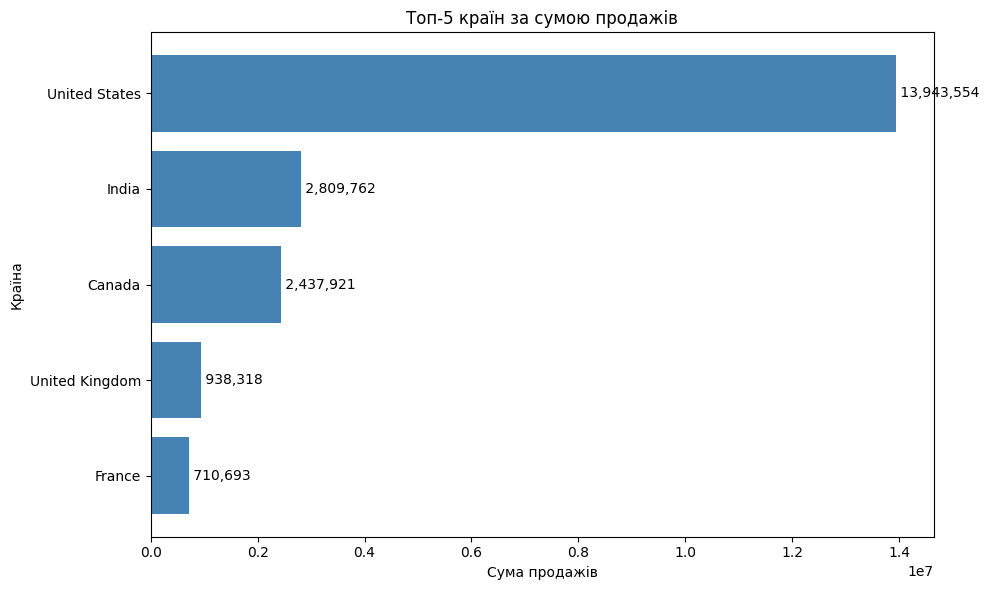

In [6]:
# Продажі тільки по рядках, де є ціна (відфільтровуємо NULL)
sales_df = df[df['price'].notnull()]

# Топ-3 континента за сумою продажів
continent_sales = sales_df.groupby('continent')["price"].sum().sort_values(ascending=False)
print("Топ-3 континента за сумою продажів:")
print(continent_sales.head(3))

# Топ-5 країн за сумою продажів
country_sales = sales_df.groupby('country')["price"].sum().sort_values(ascending=False)
print("\nТоп-5 країн за сумою продажів:")
print(country_sales.head(5))

# 3. Топ-10 категорій за сумою продажів
category_sales = sales_df.groupby('category')['price'].sum().sort_values(ascending=False)
print("\nТоп-10 категорій за сумою продажів:")
print(category_sales.head(10))
print('\n')


# Топ-5 країн за сумою продажів
top5_countries = country_sales.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top5_countries.index, top5_countries.values, color='steelblue')
plt.xlabel('Сума продажів')
plt.ylabel('Країна')
plt.title('Топ-5 країн за сумою продажів')
plt.gca().invert_yaxis()  # щоб найбільший був зверху

# Додаємо значення на планках
for i, (country, amount) in enumerate(top5_countries.items()):
    plt.text(amount, i, f' {amount:,.0f}', va='center')

plt.tight_layout()
plt.show()



##Знайди топ-10 категорій товарів у країні з найбільшими продажами, чи відрізняється ситуація від загальної?

Топ-10 категорій у США:
category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64


Топ-10 категорій глобально (для порівняння):
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children'

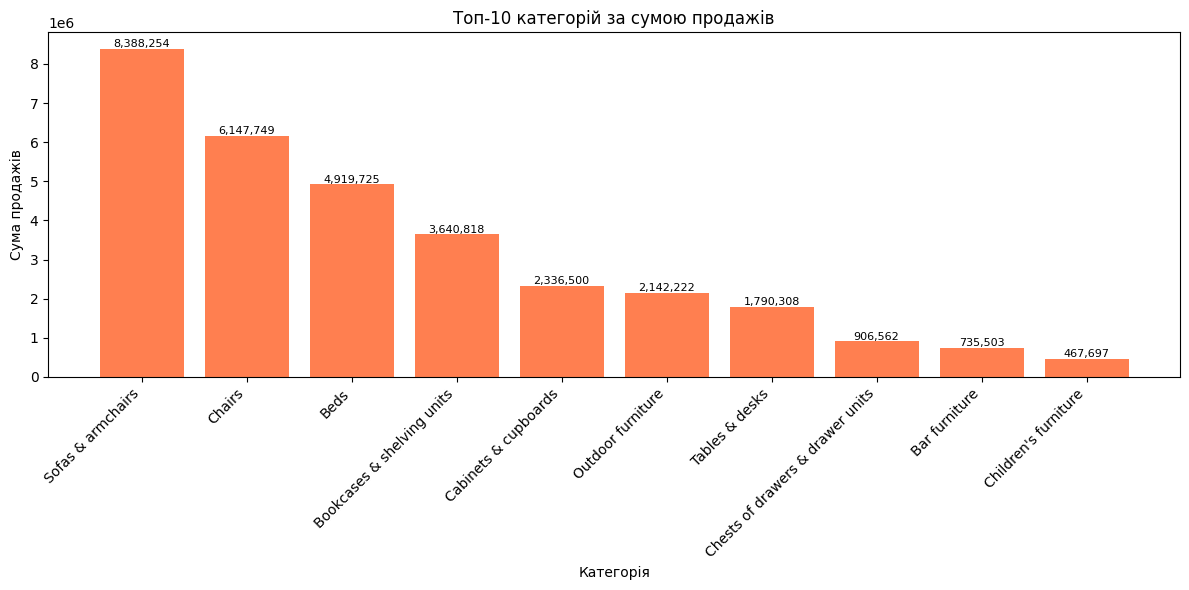

In [7]:
us_sales = sales_df[sales_df["country"] == 'United States']
us_category_sales = us_sales.groupby('category')['price'].sum().sort_values(ascending=False)

print("Топ-10 категорій у США:")
print(us_category_sales.head(10))

print("\n" + "="*50 + "\n")

print("Топ-10 категорій глобально (для порівняння):")
print(category_sales.head(10))
print('\n')

# Топ-10 категорій
top10_categories = category_sales.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_categories.index, top10_categories.values, color='coral')
plt.xlabel('Категорія')
plt.ylabel('Сума продажів')
plt.title('Топ-10 категорій за сумою продажів')
plt.xticks(rotation=45, ha='right')

# Додаємо значення над планками
for i, (cat, amount) in enumerate(top10_categories.items()):
    plt.text(i, amount + 50000, f'{amount:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

##проаналізуй продажі у розрізі типів та моделей девайсів (у % від загальних продажів)

Продажі за типами девайсів (% від загальних продажів):
  desktop: 59.0%
  mobile: 38.7%
  tablet: 2.3%

Топ-10 моделей девайсів (% від загальних продажів):
mobile_model_name
Chrome        27.8
<Other>       20.4
Safari        20.3
iPhone        20.1
ChromeBook     5.7
Edge           2.2
iPad           1.4
Firefox        1.3
Pixel 4 XL     0.4
Pixel 3        0.3
Name: price, dtype: float64




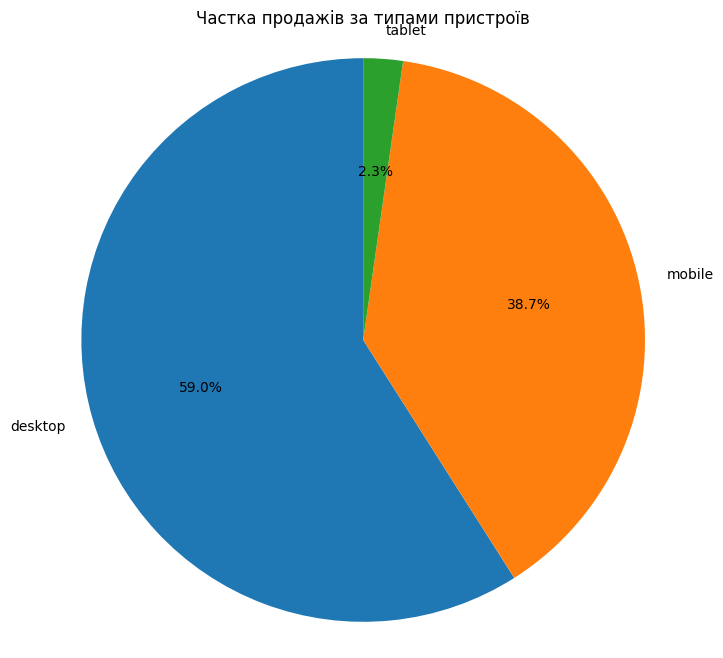

In [8]:
# Продажі у розрізі типів девайсів (%)
device_sales = sales_df.groupby('device')['price'].sum().sort_values(ascending=False)
device_percent = (device_sales / sales_df['price'].sum() * 100).round(1)

print("Продажі за типами девайсів (% від загальних продажів):")
for device, percent in device_percent.items():
    print(f"  {device}: {percent}%")

# Продажі у розрізі моделей девайсів (топ-10)
model_sales = sales_df.groupby('mobile_model_name')['price'].sum().sort_values(ascending=False)
model_percent = (model_sales / sales_df['price'].sum() * 100).round(1)

print("\nТоп-10 моделей девайсів (% від загальних продажів):")
print(model_percent.head(10))
print('\n')

plt.figure(figsize=(8, 8))
plt.pie(device_sales.values, labels=device_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Частка продажів за типами пристроїв')
plt.axis('equal')
plt.show()

## Аналiз джерел трафіку

Продажі за каналами трафіку (% від загальних продажів):
  Organic Search: 35.76%
  Paid Search: 26.62%
  Direct: 23.44%
  Social Search: 7.92%
  Undefined: 6.26%

Топ-5 джерел трафіку (% від загальних продажів):
  organic: 34.20%
  (none): 23.44%
  referral: 17.65%
  <Other>: 14.05%
  (data deleted): 6.39%




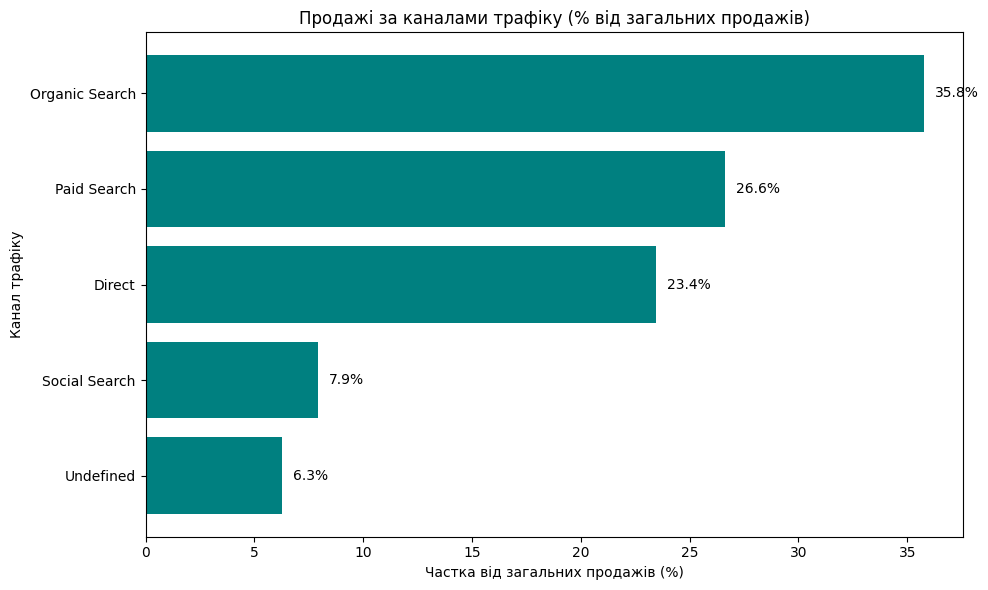

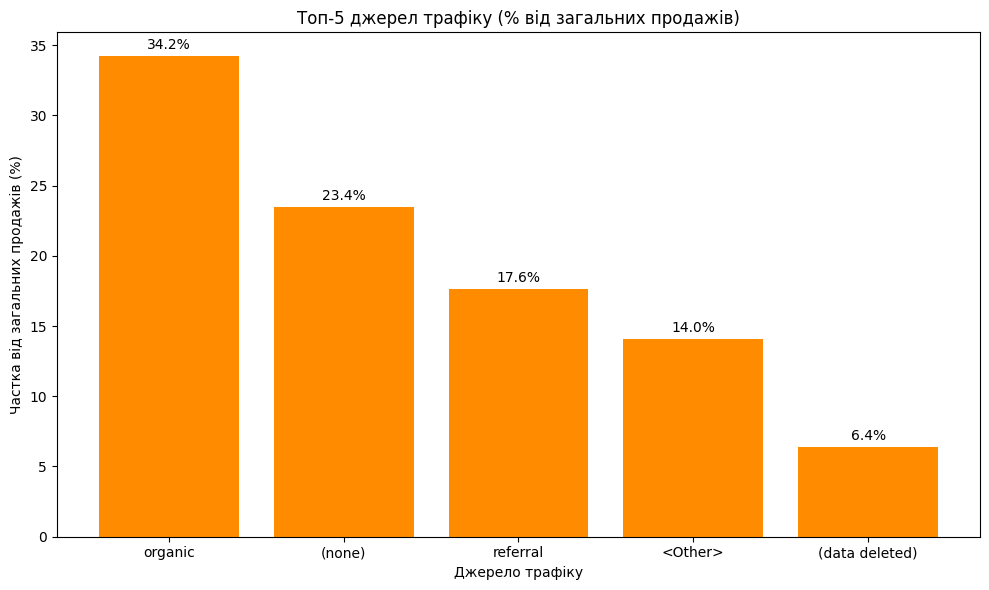

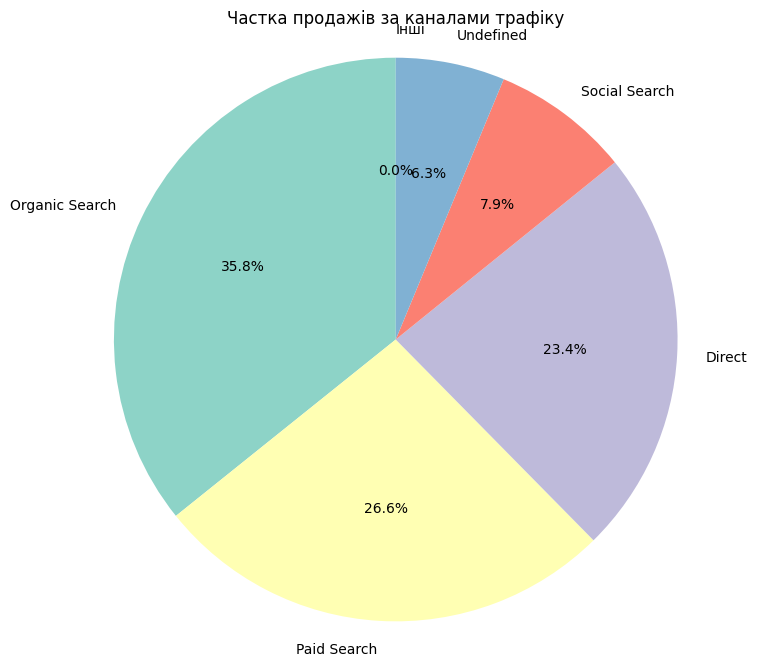

In [9]:
# Продажі за каналами трафіку (%)
channel_sales = sales_df.groupby('channel')['price'].sum().sort_values(ascending=False)
channel_percent = (channel_sales / sales_df['price'].sum() * 100)

print("Продажі за каналами трафіку (% від загальних продажів):")
for channel, percent in channel_percent.items():
    print(f"  {channel}: {percent:.2f}%")

# Продажі за джерелами трафіку (medium) - топ-5
medium_sales = sales_df.groupby('traffic_source')['price'].sum().sort_values(ascending=False)
medium_percent = (medium_sales / sales_df['price'].sum() * 100)

print("\nТоп-5 джерел трафіку (% від загальних продажів):")
for source, percent in medium_percent.head(5).items():
    print(f"  {source}: {percent:.2f}%")

print('\n')
# Підготовка даних (відсортовано за спаданням)
channels_plot = channel_percent.sort_values(ascending=True)  # для горизонтальної планки

plt.figure(figsize=(10, 6))
bars = plt.barh(channels_plot.index, channels_plot.values, color='teal')
plt.xlabel('Частка від загальних продажів (%)')
plt.ylabel('Канал трафіку')
plt.title('Продажі за каналами трафіку (% від загальних продажів)')

# Додаємо значення на планках
for i, (channel, percent) in enumerate(channels_plot.items()):
    plt.text(percent + 0.5, i, f'{percent:.1f}%', va='center')

plt.tight_layout()
plt.show()

print('\n')
# Топ-5 джерел трафіку
top5_medium = medium_percent.head(5)

plt.figure(figsize=(10, 6))
bars = plt.bar(top5_medium.index, top5_medium.values, color='darkorange')
plt.xlabel('Джерело трафіку')
plt.ylabel('Частка від загальних продажів (%)')
plt.title('Топ-5 джерел трафіку (% від загальних продажів)')

# Додаємо значення над планками
for i, (source, percent) in enumerate(top5_medium.items()):
    plt.text(i, percent + 0.5, f'{percent:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print('\n')
# Кругова діаграма для топ-5 каналів, решту об'єднуємо в "Інші"
top5_channels = channel_percent.head(5)
other_percent = channel_percent[5:].sum()

labels = list(top5_channels.index) + ['Інші']
sizes = list(top5_channels.values) + [other_percent]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('Частка продажів за каналами трафіку')
plt.axis('equal')
plt.show()

##Який відсоток зареєстрованих користувачів підтвердив свою електронну адресу?
##Який відсоток зареєстрованих користувачів відписався від розсилки?

In [10]:
# Дані тільки по зареєстрованих користувачах (де є id)
registered_df = df[df['registered_user_id'].notnull()].drop_duplicates(subset=['registered_user_id'])

# Відсоток підтверджених email
verified_percent = (registered_df['email_confirmed'].sum() / len(registered_df) * 100).round(1)
print(f"Відсоток зареєстрованих, які підтвердили email: {verified_percent}%")

# Відсоток тих, хто відписався від розсилки
unsubscribed_percent = (registered_df['unsubscribed'].sum() / len(registered_df) * 100).round(1)
print(f"Відсоток зареєстрованих, які відписалися від розсилки: {unsubscribed_percent}%")

Відсоток зареєстрованих, які підтвердили email: 71.7%
Відсоток зареєстрованих, які відписалися від розсилки: 16.9%


##чи відрізняється поведінка (у плані продажів) тих, хто відписався від розсилки та тих, хто досі підписаний?

Середня сума покупок на підписаного користувача: 921.51
Середня сума покупок на користувача, який відписався: 965.82

Медіана суми покупок (підписані): 395.00
Медіана суми покупок (відписалися): 450.00

Кількість підписаних користувачів з покупками: 2334
Кількість користувачів, які відписалися, з покупками: 447

Статистична перевірка (Mann-Whitney U test):
p-value: 0.167802
Висновок: Різниця між групами не є статистично значущою (p >= 0.05)

Графік збережено як 'analysis_chart.png'


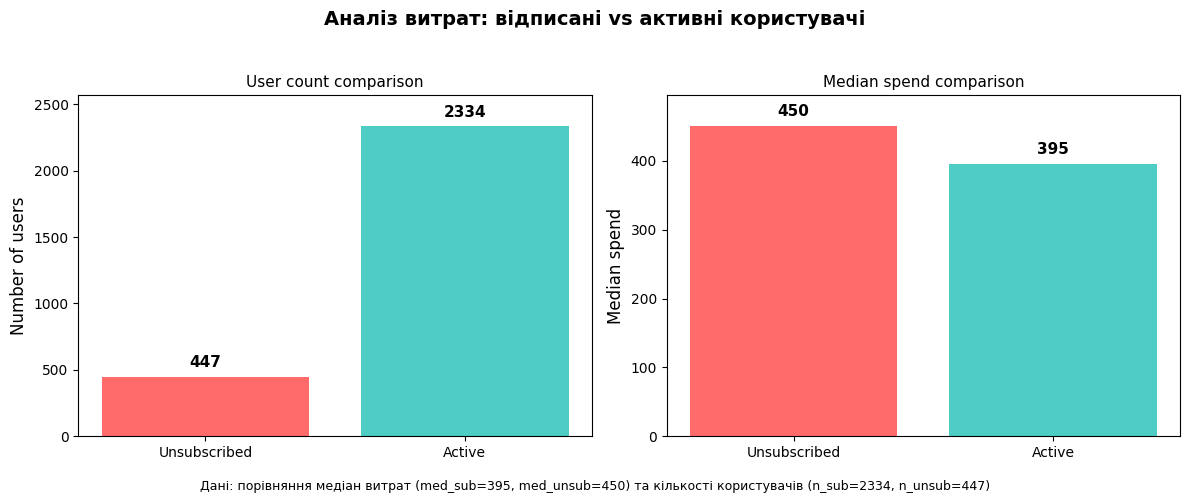


ВИСНОВОК:
Серед користувачів, які здійснили покупки, ті, хто відписався,
витрачають трохи більше (медіана 450 проти 395). Однак їхня кількість
значно менша (447 проти 2334).
Різниця в поведінці існує, але вона не драматична.


In [11]:
# ============================================
# 1. ОБРОБКА ДАНИХ ТА РОЗРАХУНКИ
# ============================================

# Дані по зареєстрованих користувачах з покупками
registered_sales = sales_df[sales_df['registered_user_id'].notnull()]

# Розділяємо на дві групи:
# 1. Підписані (не відписалися)
subscribed = registered_sales[registered_sales['unsubscribed'] == 0]
# 2. Відписалися
unsubscribed = registered_sales[registered_sales['unsubscribed'] == 1]

# Порівнюємо середню суму покупки на користувача
subscribed_avg = subscribed.groupby('registered_user_id')['price'].sum().mean()
unsubscribed_avg = unsubscribed.groupby('registered_user_id')['price'].sum().mean()

print(f"Середня сума покупок на підписаного користувача: {subscribed_avg:.2f}")
print(f"Середня сума покупок на користувача, який відписався: {unsubscribed_avg:.2f}")

# Порівнюємо медіану (більш стійка до викидів)
subscribed_median = subscribed.groupby('registered_user_id')['price'].sum().median()
unsubscribed_median = unsubscribed.groupby('registered_user_id')['price'].sum().median()

print(f"\nМедіана суми покупок (підписані): {subscribed_median:.2f}")
print(f"Медіана суми покупок (відписалися): {unsubscribed_median:.2f}")

# Кількість унікальних користувачів у кожній групі
subscribed_count = subscribed['registered_user_id'].nunique()
unsubscribed_count = unsubscribed['registered_user_id'].nunique()

print(f"\nКількість підписаних користувачів з покупками: {subscribed_count}")
print(f"Кількість користувачів, які відписалися, з покупками: {unsubscribed_count}")

# ============================================
# 2. СТАТИСТИЧНА ПЕРЕВІРКА (Mann-Whitney)
# ============================================

# Отримуємо списки сум покупок на користувача
subscribed_sums = subscribed.groupby('registered_user_id')['price'].sum()
unsubscribed_sums = unsubscribed.groupby('registered_user_id')['price'].sum()

# Перевіряємо, чи є статистично значуща різниця між групами
stat, p_value = mannwhitneyu(subscribed_sums, unsubscribed_sums, alternative='two-sided')

print(f"\nСтатистична перевірка (Mann-Whitney U test):")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Висновок: Різниця між групами є статистично значущою (p < 0.05)")
else:
    print("Висновок: Різниця між групами не є статистично значущою (p >= 0.05)")

# ============================================
# 3. ВІЗУАЛІЗАЦІЯ
# ============================================

# Дані для графіків (використовуємо розраховані значення)
groups = ['Unsubscribed', 'Active']
user_counts = [unsubscribed_count, subscribed_count]
median_spends = [unsubscribed_median, subscribed_median]

# Створюємо фігуру
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Графік 1: Кількість користувачів
bars1 = ax1.bar(groups, user_counts, color=['#FF6B6B', '#4ECDC4'])
ax1.set_ylabel('Number of users', fontsize=12)
ax1.set_title('User count comparison', fontsize=11)
ax1.set_ylim(0, max(user_counts) * 1.1)
for bar, val in zip(bars1, user_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Графік 2: Медіана витрат
bars2 = ax2.bar(groups, median_spends, color=['#FF6B6B', '#4ECDC4'])
ax2.set_ylabel('Median spend', fontsize=12)
ax2.set_title('Median spend comparison', fontsize=11)
ax2.set_ylim(0, max(median_spends) * 1.1)
for bar, val in zip(bars2, median_spends):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Налаштування відступів
plt.tight_layout(rect=[0, 0.05, 1, 0.88])

# Головний заголовок
fig.suptitle('Аналіз витрат: відписані vs активні користувачі',
             fontsize=14, fontweight='bold')

# Підпис
fig.text(0.5, 0.02, f'Дані: порівняння медіан витрат (med_sub={subscribed_median:.0f}, med_unsub={unsubscribed_median:.0f}) та кількості користувачів (n_sub={subscribed_count}, n_unsub={unsubscribed_count})',
         ha='center', fontsize=9)

# ============================================
# 4. ЗБЕРЕЖЕННЯ ГРАФІКА (опціонально)
# ============================================
plt.savefig('analysis_chart.png', dpi=300, bbox_inches='tight')
print("\nГрафік збережено як 'analysis_chart.png'")

# Відображаємо графік
plt.show()

# ============================================
# 5. ВИСНОВОК
# ============================================
print("\n" + "="*60)
print("ВИСНОВОК:")
print("="*60)
print("""Серед користувачів, які здійснили покупки, ті, хто відписався,
витрачають трохи більше (медіана {:.0f} проти {:.0f}). Однак їхня кількість
значно менша ({} проти {}).
Різниця в поведінці існує, але вона не драматична.""".format(unsubscribed_median, subscribed_median, unsubscribed_count, subscribed_count))
print("="*60)

## Знайди країни, в яких найбільше зареєстрованих користувачів (топ-10). Побудуй візуалізацію


БЛОК 1: Країни з найбільшою кількістю зареєстрованих користувачів
Топ-10 країн за кількістю реєстрацій:
country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Spain               536
Taiwan              500
China               490
Germany             490
Italy               386
Name: registered_user_id, dtype: Int64

Загальна кількість країн з реєстраціями: 108


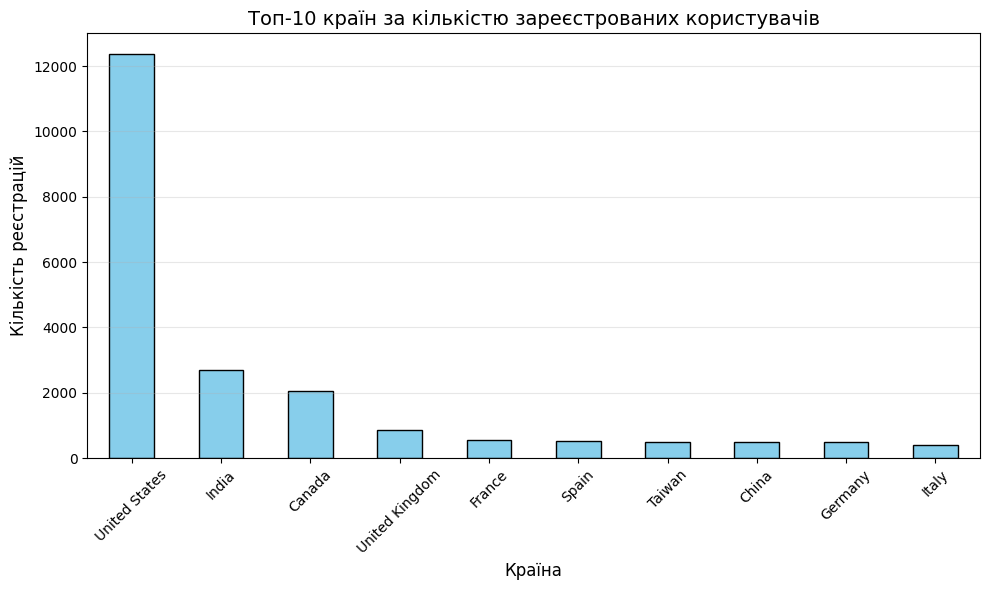

In [12]:
# ============================================
# БЛОК 1: Країни з найбільшою кількістю реєстрацій
# ============================================

print("\n" + "="*60)
print("БЛОК 1: Країни з найбільшою кількістю зареєстрованих користувачів")
print("="*60)

# Дані по зареєстрованих користувачах з географією
# Беремо унікальні пари (користувач, країна)
registered_geo = df[df['registered_user_id'].notnull()].drop_duplicates(subset=['registered_user_id', 'country'])

# Підраховуємо кількість реєстрацій по країнах
country_registrations = registered_geo.groupby('country')['registered_user_id'].count().sort_values(ascending=False)

print("Топ-10 країн за кількістю реєстрацій:")
print(country_registrations.head(10))
print(f"\nЗагальна кількість країн з реєстраціями: {len(country_registrations)}")

# Візуалізація
plt.figure(figsize=(10, 6))
country_registrations.head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Топ-10 країн за кількістю зареєстрованих користувачів', fontsize=14)
plt.xlabel('Країна', fontsize=12)
plt.ylabel('Кількість реєстрацій', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('top_countries_registrations.png', dpi=300, bbox_inches='tight')
plt.show()

## Знайди загальні продажі за кожну дату, створи візуалізацію загальної динаміки продажів. Перевір, чи спостерігається сезонність


БЛОК 2: Динаміка продажів
Період аналізу: 2020-11-01 до 2021-01-27
Кількість днів: 88


/tmp/ipykernel_5686/4258804102.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])


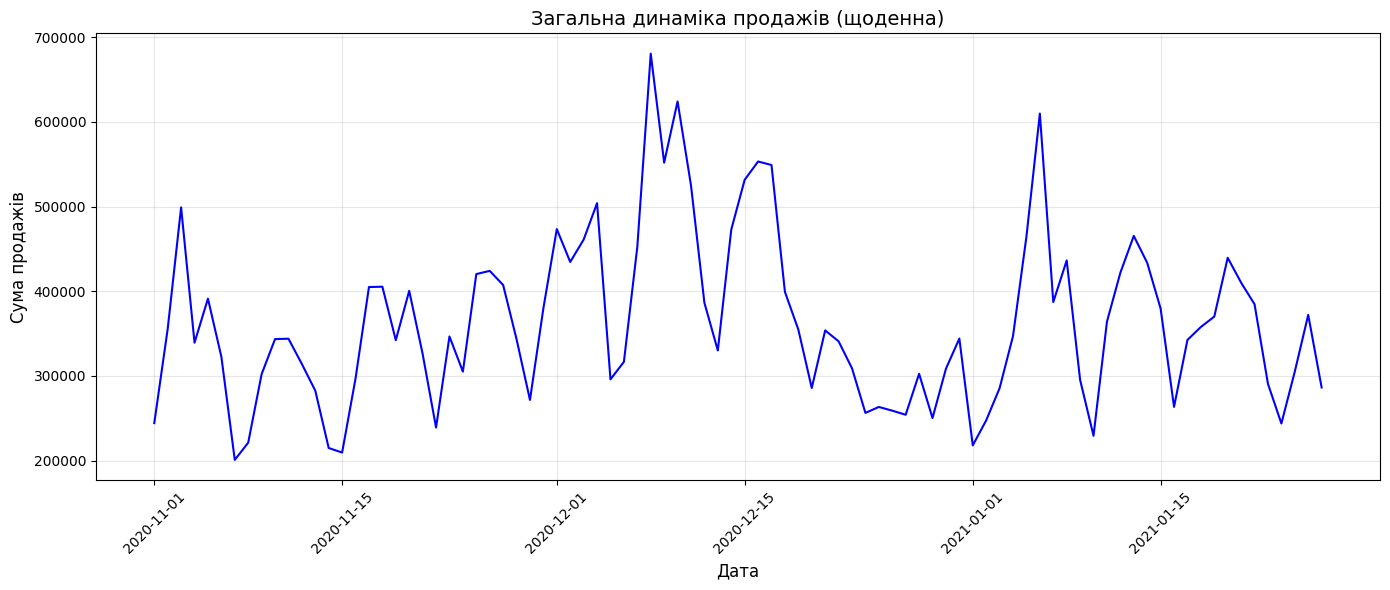


Дані є за 3 місяцями: [1, 11, 12]


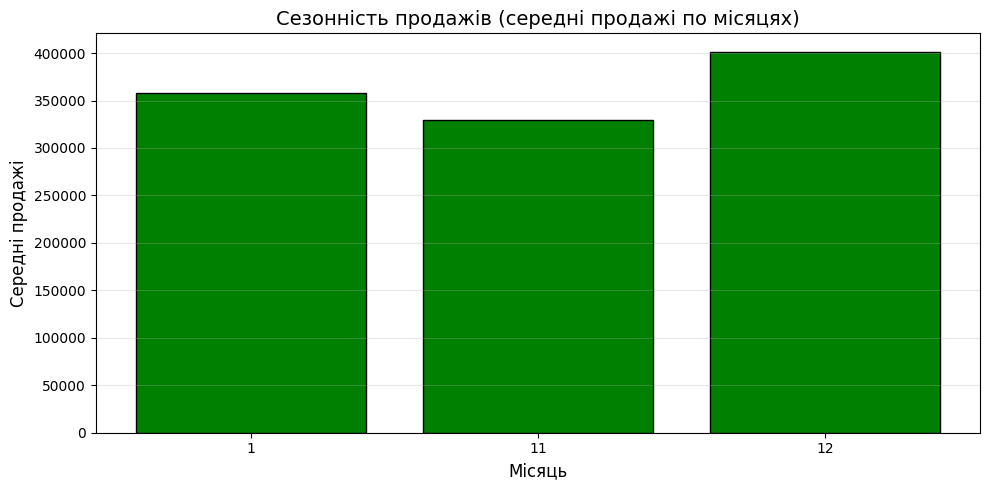


Висновок: Найвищі продажі в середньому в місяці №12, найнижчі - в місяці №11


In [13]:
# ============================================
# БЛОК 2: Динаміка продажів (загальна) - ВИПРАВЛЕНО
# ============================================

print("\n" + "="*60)
print("БЛОК 2: Динаміка продажів")
print("="*60)

# Конвертуємо дату (якщо ще не конвертували)
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])

# Групуємо по датах
daily_sales = sales_df.groupby('order_date')['price'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

print(f"Період аналізу: {daily_sales['date'].min().date()} до {daily_sales['date'].max().date()}")
print(f"Кількість днів: {len(daily_sales)}")

# Візуалізація динаміки
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['date'], daily_sales['total_sales'], color='blue', linewidth=1.5)
plt.title('Загальна динаміка продажів (щоденна)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Сума продажів', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('daily_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Аналіз сезонності (по місяцях)
daily_sales['month'] = daily_sales['date'].dt.month
monthly_avg = daily_sales.groupby('month')['total_sales'].mean()

print(f"\nДані є за {len(monthly_avg)} місяцями: {sorted(monthly_avg.index)}")

# Візуалізація сезонності (тільки ті місяці, що є в даних)
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index.astype(str), monthly_avg.values, color='green', edgecolor='black')
plt.title('Сезонність продажів (середні продажі по місяцях)', fontsize=14)
plt.xlabel('Місяць', fontsize=12)
plt.ylabel('Середні продажі', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

# Висновок
if len(monthly_avg) > 0:
    max_month = monthly_avg.idxmax()
    min_month = monthly_avg.idxmin()
    print(f"\nВисновок: Найвищі продажі в середньому в місяці №{max_month}, найнижчі - в місяці №{min_month}")
else:
    print("\nВисновок: Недостатньо даних для аналізу сезонності")

##Проаналізуй динаміку продажів в Америці, Азії та Європі. Відображай різні континенти різними кольорами


БЛОК 3: Динаміка продажів по континентах
Доступні континенти: ['Americas' 'Europe' 'Africa' 'Asia' 'Oceania' '(not set)']
Топ-3 континенти за продажами: ['Americas', 'Asia', 'Europe']


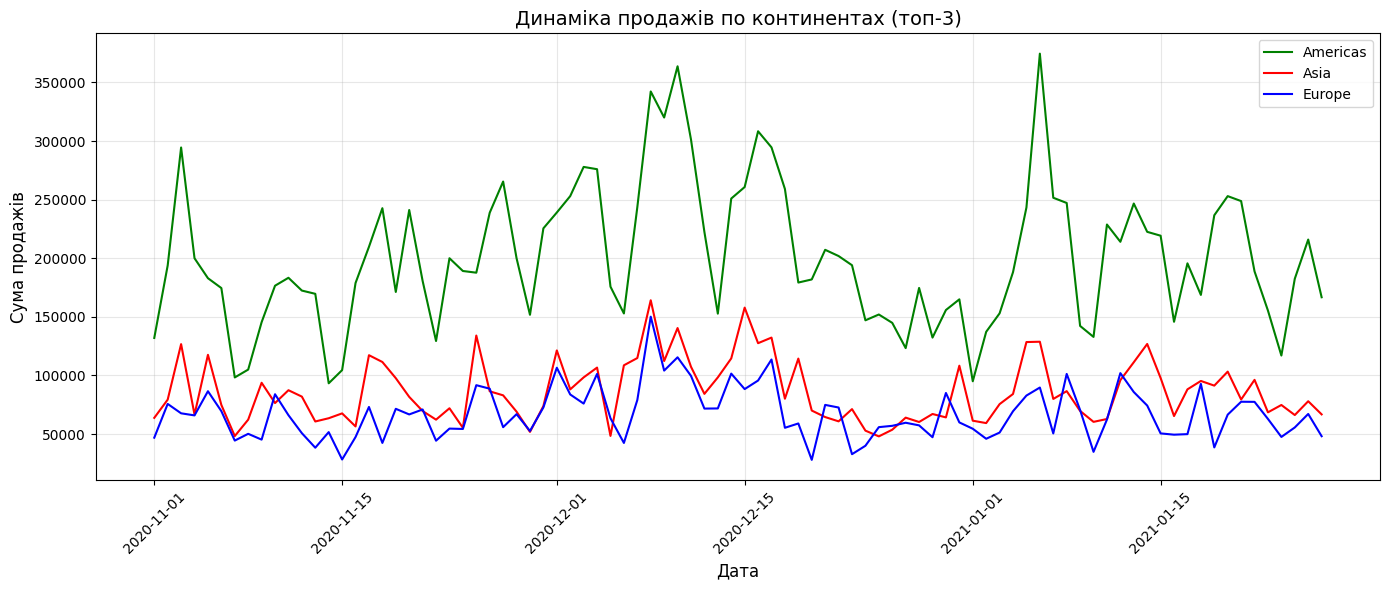


Висновки:
  - Americas: загальна сума продажів 17,665,280.00
  - Asia: загальна сума продажів 7,601,298.30
  - Europe: загальна сума продажів 5,934,624.20


In [14]:
# ============================================
# БЛОК 3: Динаміка продажів по континентах
# ============================================

print("\n" + "="*60)
print("БЛОК 3: Динаміка продажів по континентах")
print("="*60)

# Перевіряємо, які континенти є в даних
available_continents = sales_df['continent'].dropna().unique()
print(f"Доступні континенти: {available_continents}")

# Беремо топ-3 континенти за загальними продажами
continent_sales_total = sales_df.groupby('continent')['price'].sum().sort_values(ascending=False)
top_continents = continent_sales_total.head(3).index.tolist()
print(f"Топ-3 континенти за продажами: {top_continents}")

# Фільтруємо дані тільки для топ-3 континентів
sales_top_continents = sales_df[sales_df['continent'].isin(top_continents)]

# Групуємо по даті та континенту
daily_sales_by_continent = sales_top_continents.groupby(['order_date', 'continent'])['price'].sum().reset_index()

# Кольори для континентів
colors = {'Europe': 'blue', 'Asia': 'red', 'Americas': 'green', 'Africa': 'orange', 'Oceania': 'purple'}

# Візуалізація
plt.figure(figsize=(14, 6))

for continent in top_continents:
    data = daily_sales_by_continent[daily_sales_by_continent['continent'] == continent]
    color = colors.get(continent, 'gray')
    plt.plot(data['order_date'], data['price'], label=continent, color=color, linewidth=1.5)

plt.title('Динаміка продажів по континентах (топ-3)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Сума продажів', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_by_continent.png', dpi=300, bbox_inches='tight')
plt.show()

# Висновки
print("\nВисновки:")
for continent in top_continents:
    total = continent_sales_total[continent]
    print(f"  - {continent}: загальна сума продажів {total:,.2f}")

##Проаналізуй динаміку продажів у розрізі каналів трафіку. Відображай різні канали різними кольорами


БЛОК 4: Динаміка продажів по каналах трафіку
Доступні канали: ['Paid Search' 'Organic Search' 'Direct' 'Undefined' 'Social Search']
Топ-5 каналів за продажами: ['Organic Search', 'Paid Search', 'Direct', 'Social Search', 'Undefined']


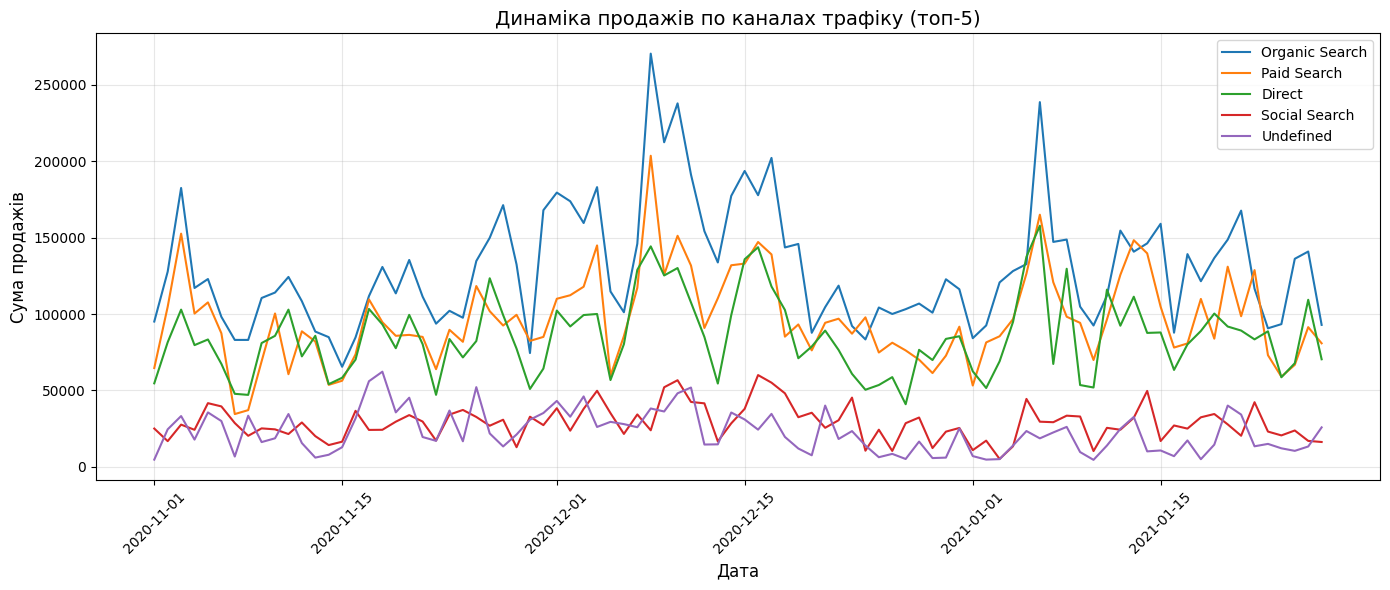


Висновки:
  - Organic Search: 11,433,151.60 (35.8% від усіх продажів)
  - Paid Search: 8,511,049.40 (26.6% від усіх продажів)
  - Direct: 7,494,923.40 (23.4% від усіх продажів)
  - Social Search: 2,532,105.70 (7.9% від усіх продажів)
  - Undefined: 2,000,501.00 (6.3% від усіх продажів)


In [15]:
# ============================================
# БЛОК 4: Динаміка продажів по каналах трафіку
# ============================================

print("\n" + "="*60)
print("БЛОК 4: Динаміка продажів по каналах трафіку")
print("="*60)

# Перевіряємо, які канали є в даних
available_channels = sales_df['channel'].dropna().unique()
print(f"Доступні канали: {available_channels}")

# Беремо топ-5 каналів за загальними продажами
channel_sales_total = sales_df.groupby('channel')['price'].sum().sort_values(ascending=False)
top_channels = channel_sales_total.head(5).index.tolist()
print(f"Топ-5 каналів за продажами: {top_channels}")

# Фільтруємо дані тільки для топ-5 каналів
sales_top_channels = sales_df[sales_df['channel'].isin(top_channels)]

# Групуємо по даті та каналу
daily_sales_by_channel = sales_top_channels.groupby(['order_date', 'channel'])['price'].sum().reset_index()

# Візуалізація
plt.figure(figsize=(14, 6))

for channel in top_channels:
    data = daily_sales_by_channel[daily_sales_by_channel['channel'] == channel]
    plt.plot(data['order_date'], data['price'], label=channel, linewidth=1.5)

plt.title('Динаміка продажів по каналах трафіку (топ-5)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Сума продажів', fontsize=12)
plt.legend(loc='best')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_by_channel.png', dpi=300, bbox_inches='tight')
plt.show()

# Висновки
print("\nВисновки:")
for channel in top_channels:
    total = channel_sales_total[channel]
    percent = (total / sales_df['price'].sum() * 100).round(1)
    print(f"  - {channel}: {total:,.2f} ({percent}% від усіх продажів)")

##Проаналізуй динаміку продажів у розрізі типів девайсів. Відображай різні девайси різними кольорами


БЛОК 5: Динаміка продажів по типах девайсів
Доступні типи девайсів: ['desktop' 'mobile' 'tablet']

Продажі за типами девайсів:
  - desktop: 59.00% (сума: 18,864,039.00)
  - mobile: 38.73% (сума: 12,384,225.80)
  - tablet: 2.26% (сума: 723,466.30)


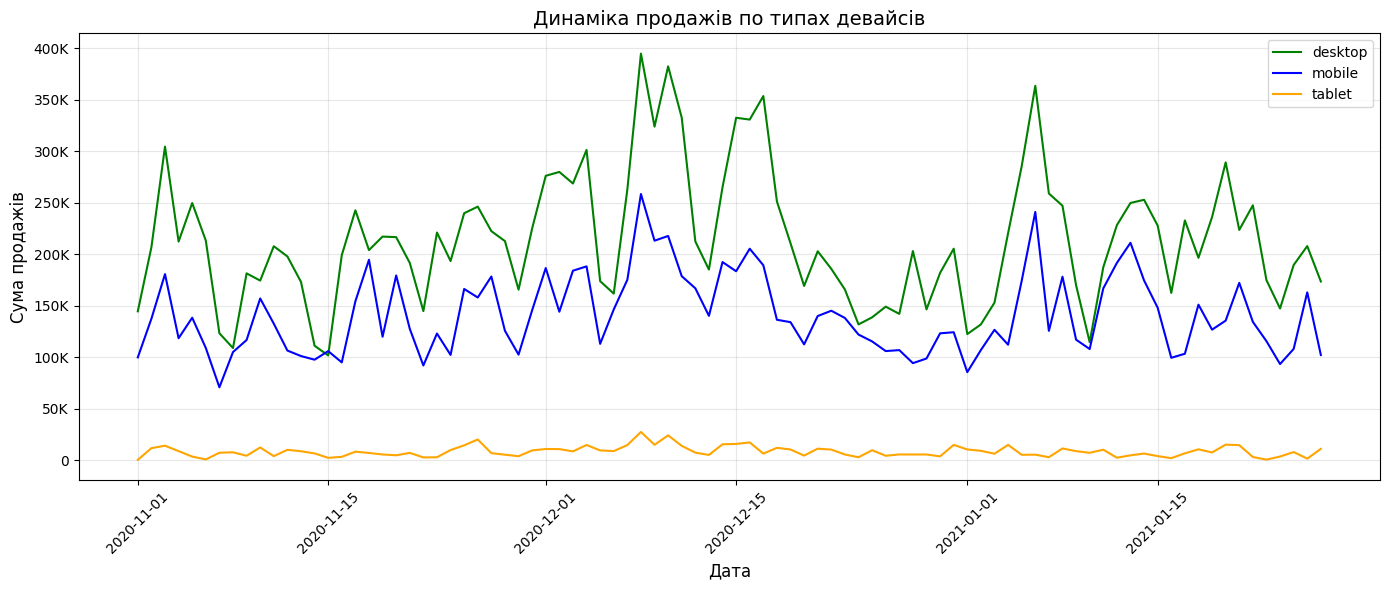

In [16]:
# ============================================
# БЛОК 5: Динаміка продажів по типах девайсів
# ============================================

print("\n" + "="*60)
print("БЛОК 5: Динаміка продажів по типах девайсів")
print("="*60)

# Перевіряємо, які типи девайсів є в даних
available_devices = sales_df['device'].dropna().unique()
print(f"Доступні типи девайсів: {available_devices}")

# Беремо всі типи девайсів з форматуванням (2 знаки після коми)
device_sales_total = sales_df.groupby('device')['price'].sum().sort_values(ascending=False)
print(f"\nПродажі за типами девайсів:")
for device, total in device_sales_total.items():
    percent = (total / sales_df['price'].sum() * 100)
    print(f"  - {device}: {percent:.2f}% (сума: {total:,.2f})")

# Групуємо по даті та типу девайсу
daily_sales_by_device = sales_df.groupby(['order_date', 'device'])['price'].sum().reset_index()

# Кольори для девайсів
device_colors = {'mobile': 'blue', 'desktop': 'green', 'tablet': 'orange'}

# Функція для форматування осі Y (скорочений вигляд: 1M, 500K)
def format_y_axis(x, p):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    else:
        return f'{x:.0f}'

# Візуалізація
plt.figure(figsize=(14, 6))

for device in device_sales_total.index:
    data = daily_sales_by_device[daily_sales_by_device['device'] == device]
    color = device_colors.get(device, 'gray')
    plt.plot(data['order_date'], data['price'], label=device, color=color, linewidth=1.5)

plt.title('Динаміка продажів по типах девайсів', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Сума продажів', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# ЗАСТОСОВУЄМО ФОРМАТУВАННЯ ОСІ Y
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_y_axis))

plt.tight_layout()
plt.savefig('sales_by_device.png', dpi=300, bbox_inches='tight')
plt.show()

##Створи зведену таблицю, яка показує кількість сесій у розрізі каналів трафіку та типів девайсів. Якщо значення якогось поля невідоме, його не враховуй.


БЛОК 6: Зведена таблиця (канали трафіку × типи девайсів)
Зведена таблиця: кількість сесій за каналами трафіку та типами девайсів
Direct               | 4,655 | 2,985 | 160
Organic Search       | 7,011 | 4,655 | 255
Paid Search          | 5,261 | 3,574 | 207
Social Search        | 1,594 | 1,065 | 57
Undefined            | 1,181 | 834 | 44

Таблиця з підсумками:
Direct               | 4,655 | 2,985 | 160 | 7,800
Organic Search       | 7,011 | 4,655 | 255 | 11,921
Paid Search          | 5,261 | 3,574 | 207 | 9,042
Social Search        | 1,594 | 1,065 | 57 | 2,716
Undefined            | 1,181 | 834 | 44 | 2,059
Total                | 19,702 | 13,113 | 723 | 33,538


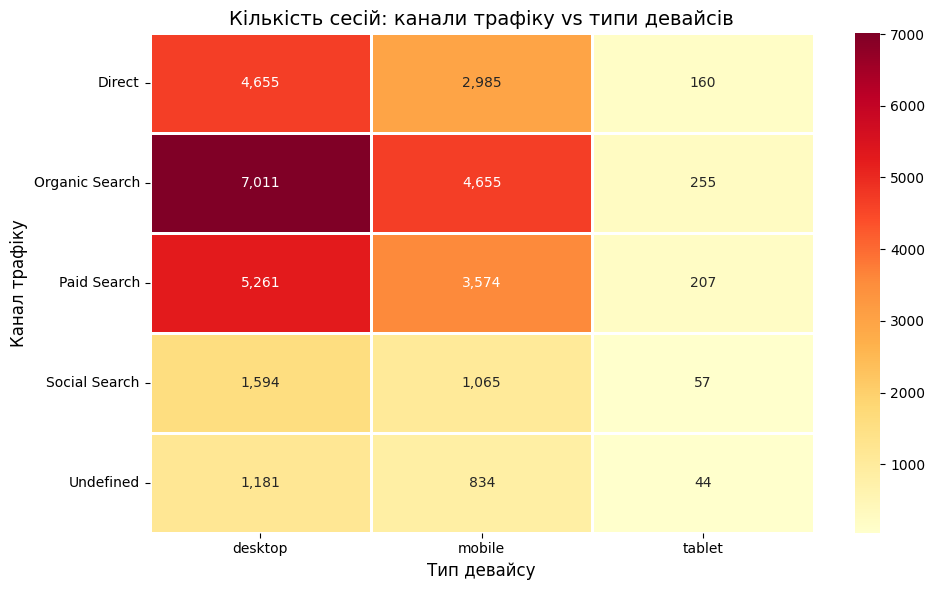


Висновки:
  - Найбільше сесій: 11,921 (канал: Organic Search, девайс: Total)


In [17]:
# ============================================
# БЛОК 6: Зведена таблиця - канали трафіку × типи девайсів
# ============================================

import matplotlib.ticker as ticker

print("\n" + "="*60)
print("БЛОК 6: Зведена таблиця (канали трафіку × типи девайсів)")
print("="*60)

# Відкидаємо рядки з невідомими значеннями
pivot_data = sales_df.dropna(subset=['channel', 'device'])

# Рахуємо кількість унікальних сесій
session_counts = pivot_data.groupby(['channel', 'device'])['ga_session_id'].nunique().reset_index()

# Створюємо зведену таблицю
pivot_channels_devices = session_counts.pivot(index='channel', columns='device', values='ga_session_id').fillna(0).astype(int)

print("Зведена таблиця: кількість сесій за каналами трафіку та типами девайсів")
print("="*50)

# Функція для форматування чисел у виводі таблиці
def format_int(x):
    return f"{x:,}"

# Виводимо таблицю з форматуванням
for idx, row in pivot_channels_devices.iterrows():
    formatted_row = [format_int(int(val)) for val in row.values]
    print(f"{idx:20} | " + " | ".join(formatted_row))

# Додаємо рядок "Всього" та колонку "Всього"
pivot_channels_devices['Total'] = pivot_channels_devices.sum(axis=1)
pivot_channels_devices.loc['Total'] = pivot_channels_devices.sum(axis=0)

print("\n" + "="*50)
print("Таблиця з підсумками:")
for idx, row in pivot_channels_devices.iterrows():
    formatted_row = [format_int(int(val)) for val in row.values]
    print(f"{idx:20} | " + " | ".join(formatted_row))

# Візуалізація (heatmap) з форматуванням чисел на клітинках
plt.figure(figsize=(10, 6))
# Видаляємо рядок Total для heatmap
heatmap_data = pivot_channels_devices.drop('Total').drop(columns='Total', errors='ignore')

# Функція для форматування чисел у heatmap (наприклад, 15,000)
def format_heatmap(x):
    return f"{int(x):,}"

# Малюємо heatmap
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=1)

# Змінюємо формат анотацій (додаємо коми як роздільник тисяч)
# Для цього потрібно оновити тексти анотацій
for text in plt.gca().texts:
    try:
        val = int(text.get_text())
        text.set_text(f"{val:,}")
    except:
        pass

plt.title('Кількість сесій: канали трафіку vs типи девайсів', fontsize=14)
plt.xlabel('Тип девайсу', fontsize=12)
plt.ylabel('Канал трафіку', fontsize=12)
plt.tight_layout()
plt.savefig('pivot_channels_devices.png', dpi=300, bbox_inches='tight')
plt.show()

# Висновки з форматуванням
print("\nВисновки:")
max_val = pivot_channels_devices.drop('Total').max().max()
max_idx = pivot_channels_devices.drop('Total').stack().idxmax()
print(f"  - Найбільше сесій: {max_val:,} (канал: {max_idx[0]}, девайс: {max_idx[1]})")

##Створи зведену таблицю, яка показує загальні продажі за категоріями товарів (топ-10 категорій) у різних країнах (топ-5 країн).


БЛОК 7: Зведена таблиця (категорії товарів × країни)
Топ-10 категорій: ['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Tables & desks', 'Chests of drawers & drawer units', 'Bar furniture', "Children's furniture"]
Топ-5 країн: ['United States', 'India', 'Canada', 'United Kingdom', 'France']

Зведена таблиця: продажі за категоріями (топ-10) та країнами (топ-5)
Sofas & armchairs                   | 692,427.50 | 187,735.00 | 788,430.00 | 234,812.00 | 3,707,144.50
Chairs                              | 417,740.80 | 134,029.40 | 544,309.20 | 188,519.40 | 2,619,773.80
Beds                                | 354,772.00 | 116,414.00 | 358,319.50 | 133,816.00 | 2,213,058.00
Bookcases & shelving units          | 278,981.90 | 73,830.00 | 364,507.40 | 113,987.60 | 1,567,606.90
Cabinets & cupboards                | 181,802.00 | 59,101.50 | 191,888.00 | 71,684.50 | 994,545.50
Outdoor furniture                   | 185,322.80 | 40,486.40

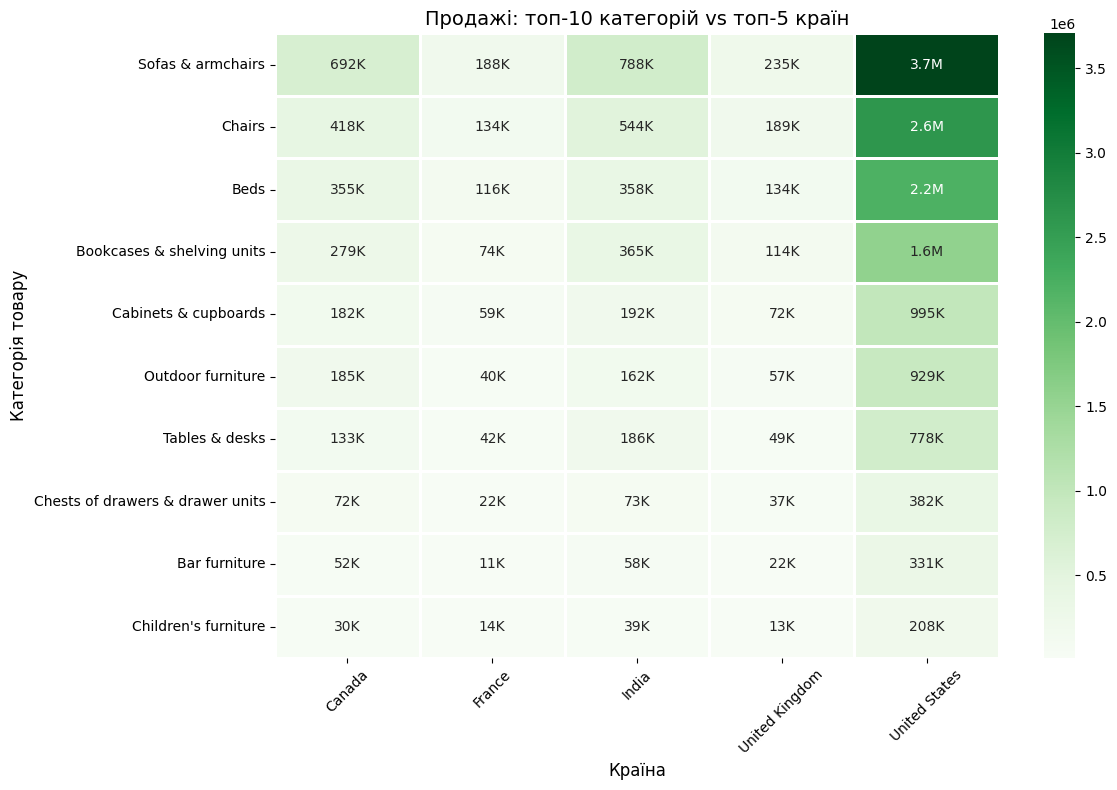


Висновки:
  - United States: загальні продажі 13,730,006.90
  - India: загальні продажі 2,765,846.00
  - Canada: загальні продажі 2,397,665.00
  - United Kingdom: загальні продажі 921,430.90
  - France: загальні продажі 700,896.80

Категорія-лідер за продажами в кожній країні:
  - United States: Sofas & armchairs (3,707,144.50)
  - India: Sofas & armchairs (788,430.00)
  - Canada: Sofas & armchairs (692,427.50)
  - United Kingdom: Sofas & armchairs (234,812.00)
  - France: Sofas & armchairs (187,735.00)


In [18]:
# ============================================
# БЛОК 7: Зведена таблиця - категорії × країни
# ============================================

import matplotlib.ticker as ticker

print("\n" + "="*60)
print("БЛОК 7: Зведена таблиця (категорії товарів × країни)")
print("="*60)

# Відкидаємо рядки з невідомими значеннями
pivot_data = sales_df.dropna(subset=['category', 'country'])

# Топ-10 категорій за продажами
top_categories = sales_df.groupby('category')['price'].sum().sort_values(ascending=False).head(10).index.tolist()
print(f"Топ-10 категорій: {top_categories}")

# Топ-5 країн за продажами
top_countries = sales_df.groupby('country')['price'].sum().sort_values(ascending=False).head(5).index.tolist()
print(f"Топ-5 країн: {top_countries}")

# Фільтруємо дані
pivot_filtered = pivot_data[pivot_data['category'].isin(top_categories) & pivot_data['country'].isin(top_countries)]

# Створюємо зведену таблицю (сума продажів)
pivot_categories_countries = pivot_filtered.pivot_table(index='category', columns='country', values='price', aggfunc='sum').fillna(0)

# Сортуємо категорії за загальними продажами
pivot_categories_countries['Total'] = pivot_categories_countries.sum(axis=1)
pivot_categories_countries = pivot_categories_countries.sort_values('Total', ascending=False)
pivot_categories_countries = pivot_categories_countries.drop('Total', axis=1)

print("\nЗведена таблиця: продажі за категоріями (топ-10) та країнами (топ-5)")
print("="*60)

# Виводимо таблицю з форматуванням (2 знаки після коми та роздільник тисяч)
for idx, row in pivot_categories_countries.iterrows():
    formatted_row = [f"{val:,.2f}" for val in row.values]
    print(f"{idx:35} | " + " | ".join(formatted_row))

# Візуалізація (heatmap) з форматуванням чисел
plt.figure(figsize=(12, 8))

# Малюємо heatmap
sns.heatmap(pivot_categories_countries, annot=True, fmt='.0f', cmap='Greens', linewidths=1)

# Змінюємо формат анотацій (додаємо коми як роздільник тисяч)
for text in plt.gca().texts:
    try:
        val = float(text.get_text())
        if val >= 1_000_000:
            text.set_text(f"{val/1_000_000:.1f}M")
        elif val >= 1_000:
            text.set_text(f"{val/1_000:.0f}K")
        else:
            text.set_text(f"{val:.0f}")
    except:
        pass

plt.title('Продажі: топ-10 категорій vs топ-5 країн', fontsize=14)
plt.xlabel('Країна', fontsize=12)
plt.ylabel('Категорія товару', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pivot_categories_countries.png', dpi=300, bbox_inches='tight')
plt.show()

# Висновки з форматуванням (роздільник тисяч та 2 знаки)
print("\nВисновки:")
for country in top_countries:
    country_total = pivot_categories_countries[country].sum()
    print(f"  - {country}: загальні продажі {country_total:,.2f}")

# Додатковий висновок: категорія-лідер у кожній країні
print("\nКатегорія-лідер за продажами в кожній країні:")
for country in top_countries:
    top_category = pivot_categories_countries[country].idxmax()
    top_value = pivot_categories_countries[country].max()
    print(f"  - {country}: {top_category} ({top_value:,.2f})")

##Знайди кількість сесій та загальні продажі за кожну дату. Створи візуалізацію, щоб побачити взаємозв'язок між цими метриками. Знайди коефіцієнт кореляції та проаналізуй його статистичну значущість.


БЛОК 8: Кореляція між кількістю сесій та продажами
  order_date  sessions     sales
0 2020-11-01       281  244292.5
1 2020-11-02       368  355506.8
2 2020-11-03       561  498979.6
3 2020-11-04       370  339187.1
4 2020-11-05       388  391276.6

Кількість днів: 88


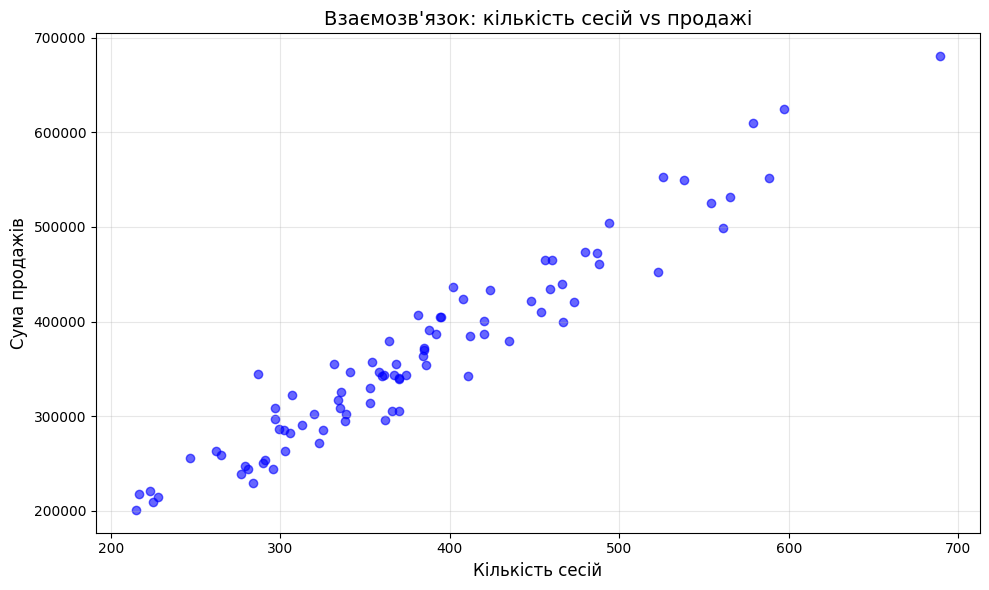


Кореляція Пірсона: 0.96, p-value: 2.24e-51
Кореляція Спірмена: 0.95, p-value: 1.35e-45

Висновок: Кореляція статистично значуща (p < 0.05)
  - Сильний позитивний зв'язок (r = 0.96)


In [19]:
# ============================================
# БЛОК 8: Кореляція - сесії vs продажі
# ============================================

print("\n" + "="*60)
print("БЛОК 8: Кореляція між кількістю сесій та продажами")
print("="*60)

# Рахуємо кількість унікальних сесій та суму продажів за дату
daily_metrics = sales_df.groupby('order_date').agg(
    sessions=('ga_session_id', 'nunique'),
    sales=('price', 'sum')
).reset_index()

print(daily_metrics.head())
print(f"\nКількість днів: {len(daily_metrics)}")

# Візуалізація взаємозв'язку (scatter plot)
plt.figure(figsize=(10, 6))
plt.scatter(daily_metrics['sessions'], daily_metrics['sales'], alpha=0.6, color='blue')
plt.xlabel('Кількість сесій', fontsize=12)
plt.ylabel('Сума продажів', fontsize=12)
plt.title('Взаємозв\'язок: кількість сесій vs продажі', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('correlation_sessions_sales_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Розрахунок кореляції Пірсона
pearson_corr, pearson_p = pearsonr(daily_metrics['sessions'], daily_metrics['sales'])

# Розрахунок кореляції Спірмена (для нелінійних зв'язків)
spearman_corr, spearman_p = spearmanr(daily_metrics['sessions'], daily_metrics['sales'])


print(f"\nКореляція Пірсона: {pearson_corr:.2f}, p-value: {pearson_p:.2e}" if pearson_p < 0.001 else f"p-value: {pearson_p:.2f}")
print(f"Кореляція Спірмена: {spearman_corr:.2f}, p-value: {spearman_p:.2e}" if spearman_p < 0.001 else f"p-value: {spearman_p:.2f}")

# Аналіз значущості
if pearson_p < 0.05:
    print(f"\nВисновок: Кореляція статистично значуща (p < 0.05)")
    if abs(pearson_corr) > 0.7:
        print(f"  - Сильний {'позитивний' if pearson_corr > 0 else 'негативний'} зв'язок (r = {pearson_corr:.2f})")
    elif abs(pearson_corr) > 0.3:
        print(f"  - Помірний {'позитивний' if pearson_corr > 0 else 'негативний'} зв'язок (r = {pearson_corr:.2f})")
    else:
        print(f"  - Слабкий {'позитивний' if pearson_corr > 0 else 'негативний'} зв'язок (r = {pearson_corr:.2f})")
else:
    print(f"\nВисновок: Кореляція не є статистично значущою (p >= 0.05)")

##Кореляційний аналіз (континенти, канали, категорії)


БЛОК 9: Кореляційний аналіз продажів

----------------------------------------
9.1 Кореляція між континентами
----------------------------------------
Топ-3 континенти: ['Americas', 'Asia', 'Europe']

Кореляційна матриця (континенти):
continent  Americas  Asia  Europe
continent                        
Americas       1.00  0.69    0.67
Asia           0.69  1.00    0.67
Europe         0.67  0.67    1.00


/tmp/ipykernel_5686/2352467041.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])


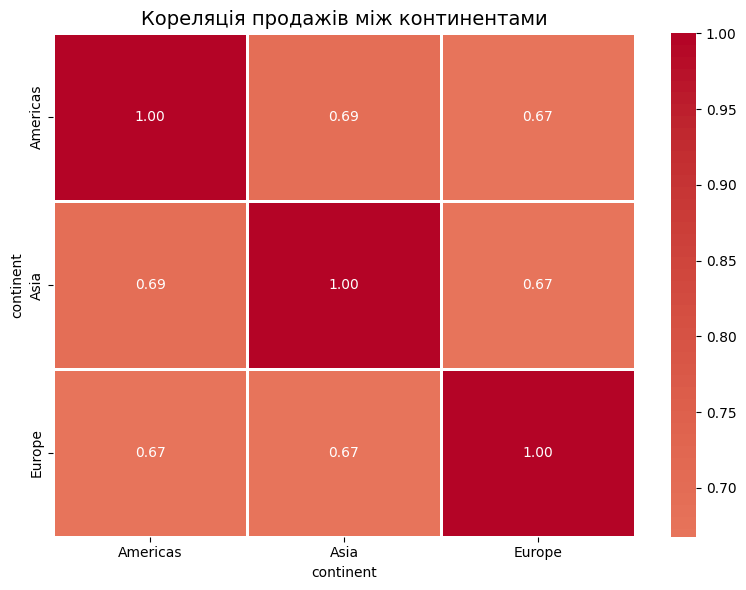


Статистична значущість кореляцій між континентами:
  Americas vs Asia: r = 0.69, p-value = 8.00e-14
    → Кореляція статистично значуща (p < 0.05)
  Americas vs Europe: r = 0.67, p-value = 9.91e-13
    → Кореляція статистично значуща (p < 0.05)
  Asia vs Europe: r = 0.67, p-value = 1.19e-12
    → Кореляція статистично значуща (p < 0.05)

----------------------------------------
9.2 Кореляція між каналами трафіку
----------------------------------------
Топ-5 каналів: ['Organic Search', 'Paid Search', 'Direct', 'Social Search', 'Undefined']

Кореляційна матриця (канали трафіку):
channel         Organic Search  Paid Search  Direct  Social Search  Undefined
channel                                                                      
Organic Search            1.00         0.81    0.76           0.43       0.44
Paid Search               0.81         1.00    0.72           0.45       0.43
Direct                    0.76         0.72    1.00           0.46       0.42
Social Search           

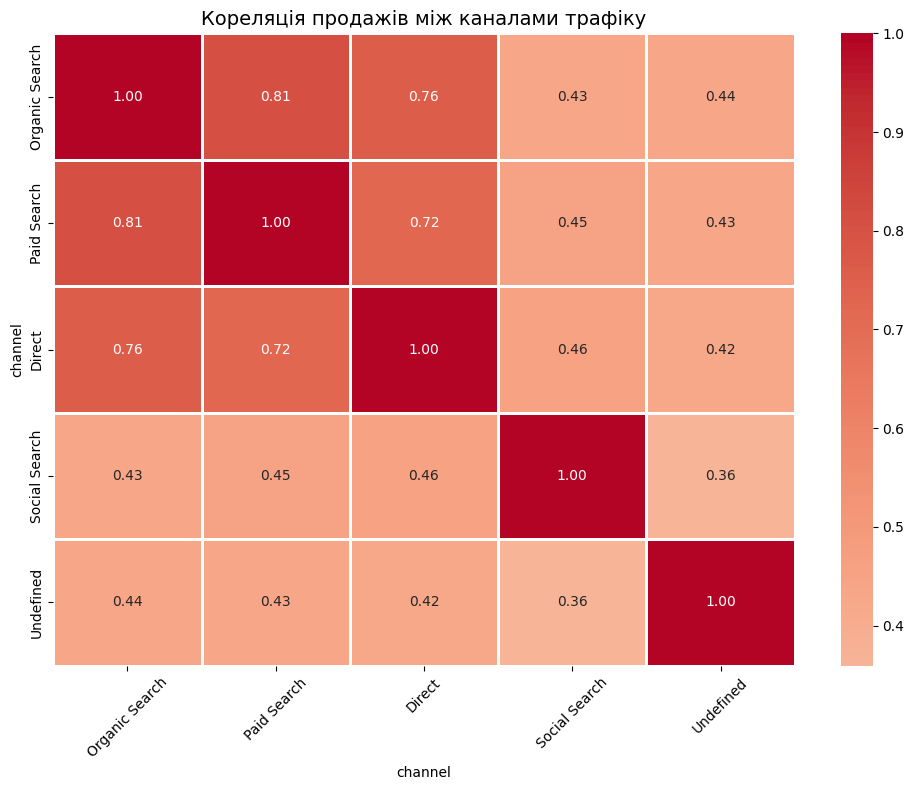


----------------------------------------
9.3 Кореляція між категоріями товарів
----------------------------------------
Топ-5 категорій: ['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']

Кореляційна матриця (категорії товарів):
category                    Sofas & armchairs  Chairs  Beds  \
category                                                      
Sofas & armchairs                        1.00    0.58  0.54   
Chairs                                   0.58    1.00  0.55   
Beds                                     0.54    0.55  1.00   
Bookcases & shelving units               0.67    0.64  0.59   
Cabinets & cupboards                     0.66    0.57  0.51   

category                    Bookcases & shelving units  Cabinets & cupboards  
category                                                                      
Sofas & armchairs                                 0.67                  0.66  
Chairs                                         

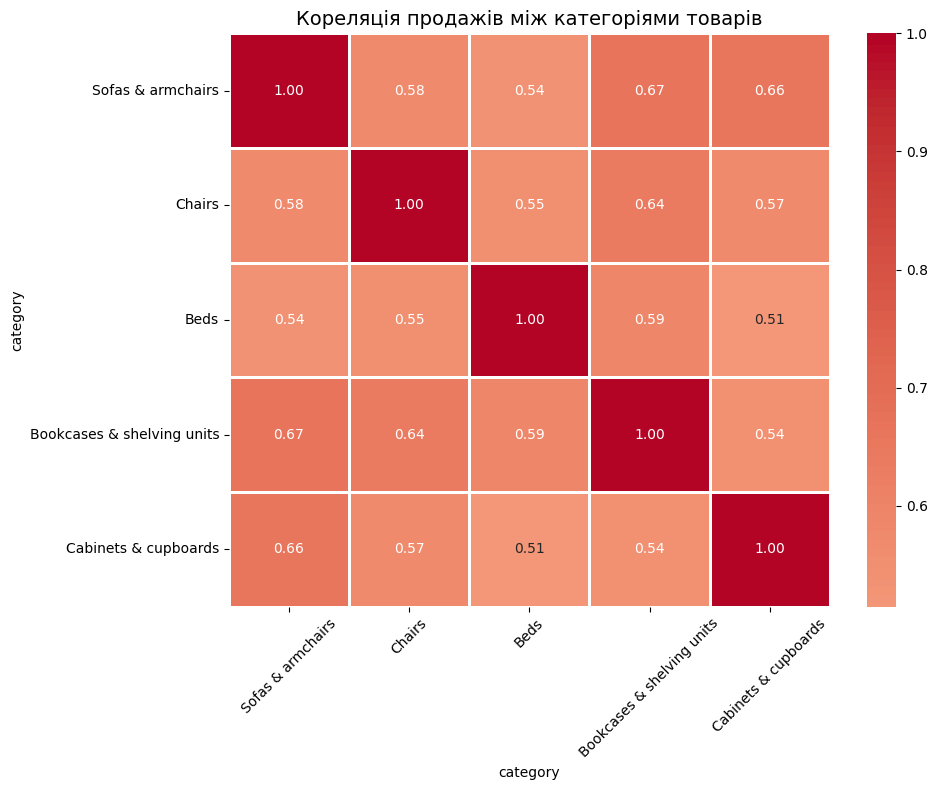


ЗАГАЛЬНІ ВИСНОВКИ З КОРЕЛЯЦІЙНОГО АНАЛІЗУ

Найсильніші позитивні кореляції:
  - Organic Search ↔ Paid Search: 0.81
  - Organic Search ↔ Direct: 0.76
  - Paid Search ↔ Direct: 0.72
  - Sofas & armchairs ↔ Chairs: 0.58
  - Sofas & armchairs ↔ Beds: 0.54
  - Sofas & armchairs ↔ Bookcases & shelving units: 0.67
  - Sofas & armchairs ↔ Cabinets & cupboards: 0.66
  - Chairs ↔ Beds: 0.55
  - Chairs ↔ Bookcases & shelving units: 0.64
  - Chairs ↔ Cabinets & cupboards: 0.57
  - Beds ↔ Bookcases & shelving units: 0.59
  - Beds ↔ Cabinets & cupboards: 0.51
  - Bookcases & shelving units ↔ Cabinets & cupboards: 0.54

Найсильніші негативні кореляції (можуть свідчити про заміщення):


In [20]:
# ============================================
# БЛОК 9: Кореляційний аналіз
# ============================================

print("\n" + "="*60)
print("БЛОК 9: Кореляційний аналіз продажів")
print("="*60)

# Підготовка: переконуємось, що дата у правильному форматі
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])

# ============================================
# 9.1 Кореляція між континентами (топ-3)
# ============================================

print("\n" + "-"*40)
print("9.1 Кореляція між континентами")
print("-"*40)

# Отримуємо топ-3 континенти за продажами
continent_sales_total = sales_df.groupby('continent')['price'].sum().sort_values(ascending=False)
top_continents = continent_sales_total.head(3).index.tolist()
print(f"Топ-3 континенти: {top_continents}")

# Створюємо daily продажі по континентах
daily_continent = sales_df.groupby(['order_date', 'continent'])['price'].sum().reset_index()

# Створюємо таблицю для кореляції
continent_pivot = daily_continent.pivot(index='order_date', columns='continent', values='price').fillna(0)

# Беремо тільки топ-3 континенти
continent_pivot_top = continent_pivot[top_continents]

# Розраховуємо кореляцію
continent_corr = continent_pivot_top.corr()

print("\nКореляційна матриця (континенти):")
print(continent_corr.round(2))

# Візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(continent_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=1)
plt.title('Кореляція продажів між континентами', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_continents.png', dpi=300, bbox_inches='tight')
plt.show()

# Статистична значущість для кожної пари
from scipy.stats import pearsonr
print("\nСтатистична значущість кореляцій між континентами:")
for i in range(len(top_continents)):
    for j in range(i+1, len(top_continents)):
        cont1, cont2 = top_continents[i], top_continents[j]
        # Видаляємо дні, коли в обох континентах були нулі
        mask = (continent_pivot_top[cont1] != 0) | (continent_pivot_top[cont2] != 0)
        data1 = continent_pivot_top.loc[mask, cont1]
        data2 = continent_pivot_top.loc[mask, cont2]
        if len(data1) > 2:
            corr, p_value = pearsonr(data1, data2)
            if p_value < 0.001:
                print(f"  {cont1} vs {cont2}: r = {corr:.2f}, p-value = {p_value:.2e}")
            else:
                print(f"  {cont1} vs {cont2}: r = {corr:.2f}, p-value = {p_value:.2f}")
            print(f"    → Кореляція {'статистично значуща' if p_value < 0.05 else 'не є статистично значущою'} (p {'<' if p_value < 0.05 else '>='} 0.05)")

# ============================================
# 9.2 Кореляція між каналами трафіку (топ-5)
# ============================================

print("\n" + "-"*40)
print("9.2 Кореляція між каналами трафіку")
print("-"*40)

# Отримуємо топ-5 каналів за продажами
channel_sales_total = sales_df.groupby('channel')['price'].sum().sort_values(ascending=False)
top_channels = channel_sales_total.head(5).index.tolist()
print(f"Топ-5 каналів: {top_channels}")

# Створюємо daily продажі по каналах
daily_channel = sales_df.groupby(['order_date', 'channel'])['price'].sum().reset_index()

# Створюємо таблицю для кореляції
channel_pivot = daily_channel.pivot(index='order_date', columns='channel', values='price').fillna(0)

# Беремо тільки топ-5 каналів
channel_pivot_top = channel_pivot[top_channels]

# Розраховуємо кореляцію
channel_corr = channel_pivot_top.corr()

print("\nКореляційна матриця (канали трафіку):")
print(channel_corr.round(2))

# Візуалізація
plt.figure(figsize=(10, 8))
sns.heatmap(channel_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=1)
plt.title('Кореляція продажів між каналами трафіку', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('correlation_channels.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 9.3 Кореляція між категоріями товарів (топ-5)
# ============================================

print("\n" + "-"*40)
print("9.3 Кореляція між категоріями товарів")
print("-"*40)

# Отримуємо топ-5 категорій за продажами
category_sales_total = sales_df.groupby('category')['price'].sum().sort_values(ascending=False)
top_categories = category_sales_total.head(5).index.tolist()
print(f"Топ-5 категорій: {top_categories}")

# Створюємо daily продажі по категоріях
daily_category = sales_df.groupby(['order_date', 'category'])['price'].sum().reset_index()

# Створюємо таблицю для кореляції
category_pivot = daily_category.pivot(index='order_date', columns='category', values='price').fillna(0)

# Беремо тільки топ-5 категорій
category_pivot_top = category_pivot[top_categories]

# Розраховуємо кореляцію
category_corr = category_pivot_top.corr()

print("\nКореляційна матриця (категорії товарів):")
print(category_corr.round(2))

# Візуалізація
plt.figure(figsize=(10, 8))
sns.heatmap(category_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=1)
plt.title('Кореляція продажів між категоріями товарів', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('correlation_categories.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# ЗАГАЛЬНІ ВИСНОВКИ
# ============================================

print("\n" + "="*60)
print("ЗАГАЛЬНІ ВИСНОВКИ З КОРЕЛЯЦІЙНОГО АНАЛІЗУ")
print("="*60)

# Знаходимо найсильніші кореляції
print("\nНайсильніші позитивні кореляції:")

# По каналах
for i in range(len(top_channels)):
    for j in range(i+1, len(top_channels)):
        corr_val = channel_corr.iloc[i, j]
        if corr_val > 0.5:
            print(f"  - {top_channels[i]} ↔ {top_channels[j]}: {corr_val:.2f}")

# По категоріях
for i in range(len(top_categories)):
    for j in range(i+1, len(top_categories)):
        corr_val = category_corr.iloc[i, j]
        if corr_val > 0.5:
            print(f"  - {top_categories[i]} ↔ {top_categories[j]}: {corr_val:.2f}")

print("\nНайсильніші негативні кореляції (можуть свідчити про заміщення):")
for i in range(len(top_categories)):
    for j in range(i+1, len(top_categories)):
        corr_val = category_corr.iloc[i, j]
        if corr_val < -0.3:
            print(f"  - {top_categories[i]} ↔ {top_categories[j]}: {corr_val:.2f}")

##Проаналізуй продажі за кожну дату зареєстрованих та незареєстрованих користувачів. Створи відповідні вибірки, проаналізуй розподіли даних в обох вибірках. Підбери відповідний статистичний тест для порівняння вибірок. Зроби висновок щодо статистичної значущості отриманих результатів.




БЛОК 10: Порівняння продажів зареєстрованих та незареєстрованих користувачів
Кількість зареєстрованих користувачів з покупками: 2781
Кількість незареєстрованих користувачів (сесій): 30757
Сума продажів (зареєстровані): 2,582,518.50
Сума продажів (незареєстровані): 29,389,212.60

Кількість днів для аналізу: 88

----------------------------------------
10.1 Аналіз розподілів
----------------------------------------


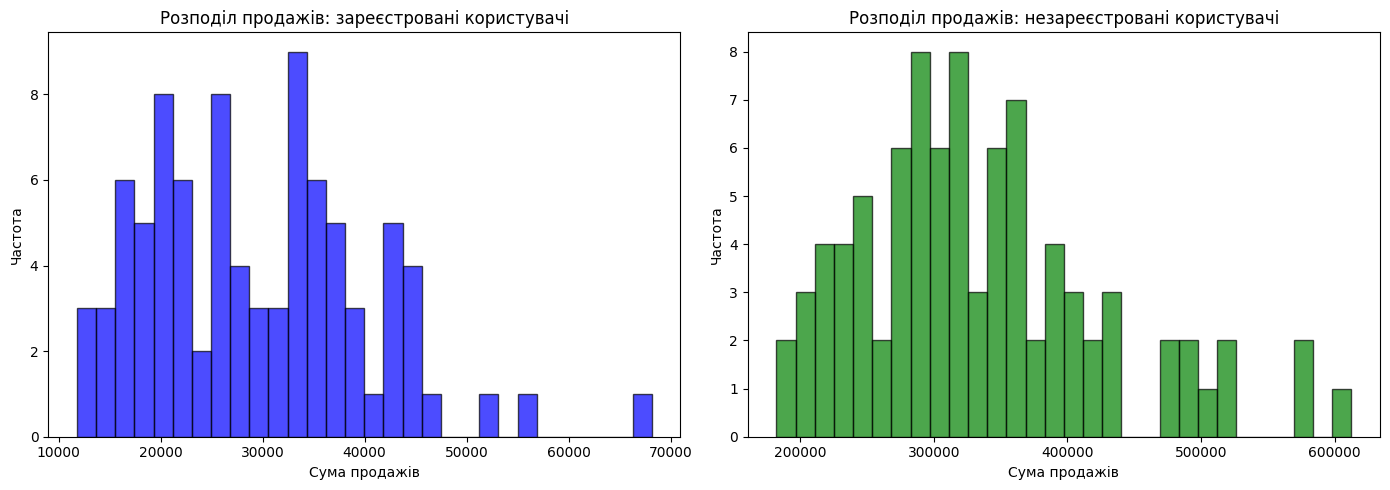


Перевірка на нормальність (Shapiro-Wilk):
  Зареєстровані: W = 0.9592, p-value = 0.007295
  Незареєстровані: W = 0.9522, p-value = 0.002618
  → Розподіл зареєстрованих НЕ є нормальним
  → Розподіл незареєстрованих НЕ є нормальним

----------------------------------------
10.2 Порівняння вибірок
----------------------------------------
Mann-Whitney U test:
  U statistic: 0.0000
  p-value: 0.000000

t-test (для довідки):
  t-statistic: -30.5522
  p-value: 0.000000

----------------------------------------
10.3 Висновки
----------------------------------------

Середні продажі на день:
  Зареєстровані: 29346.80
  Незареєстровані: 333968.33

Медіанні продажі на день:
  Зареєстровані: 28048.00
  Незареєстровані: 316724.25

✅ ВИСНОВОК: Різниця між групами є статистично значущою (p = 0.000000 < 0.05)
  → Незареєстровані користувачі приносять більше продажів, ніж зареєстровані


/tmp/ipykernel_5686/2179734060.py:149: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Registered', 'Non-registered'], patch_artist=True)


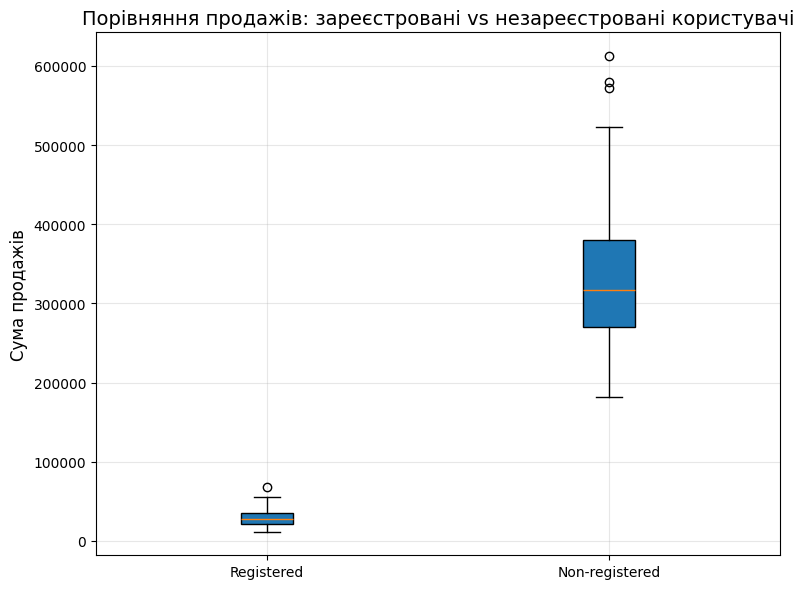

In [21]:
# ============================================
# БЛОК 10: Статистичний тест - зареєстровані vs незареєстровані користувачі
# ============================================

print("\n" + "="*60)
print("БЛОК 10: Порівняння продажів зареєстрованих та незареєстрованих користувачів")
print("="*60)

from scipy.stats import shapiro, mannwhitneyu, ttest_ind

# Створюємо вибірки
# Зареєстровані користувачі (є registered_user_id)
registered_users = sales_df[sales_df['registered_user_id'].notnull()]

# Незареєстровані користувачі (немає registered_user_id)
non_registered_users = sales_df[sales_df['registered_user_id'].isnull()]

print(f"Кількість зареєстрованих користувачів з покупками: {registered_users['registered_user_id'].nunique()}")
print(f"Кількість незареєстрованих користувачів (сесій): {non_registered_users['ga_session_id'].nunique()}")
print(f"Сума продажів (зареєстровані): {registered_users['price'].sum():,.2f}")
print(f"Сума продажів (незареєстровані): {non_registered_users['price'].sum():,.2f}")

# Групуємо по датах для щоденного аналізу
daily_registered = registered_users.groupby('order_date')['price'].sum().reset_index()
daily_registered.columns = ['date', 'registered_sales']

daily_non_registered = non_registered_users.groupby('order_date')['price'].sum().reset_index()
daily_non_registered.columns = ['date', 'non_registered_sales']

# Об'єднуємо
daily_sales_compare = pd.merge(daily_registered, daily_non_registered, on='date', how='outer').fillna(0)

print(f"\nКількість днів для аналізу: {len(daily_sales_compare)}")

# ============================================
# 10.1 Аналіз розподілів
# ============================================

print("\n" + "-"*40)
print("10.1 Аналіз розподілів")
print("-"*40)

# Візуалізація розподілів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гістограма для зареєстрованих
axes[0].hist(daily_sales_compare['registered_sales'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Розподіл продажів: зареєстровані користувачі', fontsize=12)
axes[0].set_xlabel('Сума продажів')
axes[0].set_ylabel('Частота')

# Гістограма для незареєстрованих
axes[1].hist(daily_sales_compare['non_registered_sales'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Розподіл продажів: незареєстровані користувачі', fontsize=12)
axes[1].set_xlabel('Сума продажів')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('distribution_registered_vs_nonregistered.png', dpi=300, bbox_inches='tight')
plt.show()

# Перевірка на нормальність (Shapiro-Wilk test)
# Беремо тільки ненульові значення
registered_nonzero = daily_sales_compare['registered_sales'][daily_sales_compare['registered_sales'] > 0]
non_registered_nonzero = daily_sales_compare['non_registered_sales'][daily_sales_compare['non_registered_sales'] > 0]

if len(registered_nonzero) > 3 and len(non_registered_nonzero) > 3:
    shapiro_reg, p_reg = shapiro(registered_nonzero)
    shapiro_nonreg, p_nonreg = shapiro(non_registered_nonzero)

    print(f"\nПеревірка на нормальність (Shapiro-Wilk):")
    print(f"  Зареєстровані: W = {shapiro_reg:.4f}, p-value = {p_reg:.6f}")
    print(f"  Незареєстровані: W = {shapiro_nonreg:.4f}, p-value = {p_nonreg:.6f}")

    if p_reg < 0.05:
        print("  → Розподіл зареєстрованих НЕ є нормальним")
    else:
        print("  → Розподіл зареєстрованих є нормальним")

    if p_nonreg < 0.05:
        print("  → Розподіл незареєстрованих НЕ є нормальним")
    else:
        print("  → Розподіл незареєстрованих є нормальним")

# ============================================
# 10.2 Вибір статистичного тесту
# ============================================

print("\n" + "-"*40)
print("10.2 Порівняння вибірок")
print("-"*40)

# Оскільки розподіли, швидше за все, не нормальні - використовуємо Mann-Whitney U test
stat, p_value = mannwhitneyu(
    daily_sales_compare['registered_sales'],
    daily_sales_compare['non_registered_sales'],
    alternative='two-sided'
)

print(f"Mann-Whitney U test:")
print(f"  U statistic: {stat:.4f}")
print(f"  p-value: {p_value:.6f}")

# Додатково - t-test для порівняння (хоча дані можуть бути не нормальними)
t_stat, t_p = ttest_ind(
    daily_sales_compare['registered_sales'],
    daily_sales_compare['non_registered_sales']
)

print(f"\nt-test (для довідки):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {t_p:.6f}")

# ============================================
# 10.3 Висновки
# ============================================

print("\n" + "-"*40)
print("10.3 Висновки")
print("-"*40)

# Середні значення
mean_reg = daily_sales_compare['registered_sales'].mean()
mean_nonreg = daily_sales_compare['non_registered_sales'].mean()
median_reg = daily_sales_compare['registered_sales'].median()
median_nonreg = daily_sales_compare['non_registered_sales'].median()

print(f"\nСередні продажі на день:")
print(f"  Зареєстровані: {mean_reg:.2f}")
print(f"  Незареєстровані: {mean_nonreg:.2f}")

print(f"\nМедіанні продажі на день:")
print(f"  Зареєстровані: {median_reg:.2f}")
print(f"  Незареєстровані: {median_nonreg:.2f}")

if p_value < 0.05:
    print(f"\n✅ ВИСНОВОК: Різниця між групами є статистично значущою (p = {p_value:.6f} < 0.05)")
    if mean_reg > mean_nonreg:
        print(f"  → Зареєстровані користувачі приносять більше продажів, ніж незареєстровані")
    else:
        print(f"  → Незареєстровані користувачі приносять більше продажів, ніж зареєстровані")
else:
    print(f"\n❌ ВИСНОВОК: Різниця між групами НЕ є статистично значущою (p = {p_value:.6f} >= 0.05)")
    print(f"  → Продажі зареєстрованих та незареєстрованих користувачів статистично не відрізняються")

# Візуалізація порівняння (boxplot)
plt.figure(figsize=(8, 6))
data_to_plot = [daily_sales_compare['registered_sales'], daily_sales_compare['non_registered_sales']]
plt.boxplot(data_to_plot, labels=['Registered', 'Non-registered'], patch_artist=True)
plt.title('Порівняння продажів: зареєстровані vs незареєстровані користувачі', fontsize=14)
plt.ylabel('Сума продажів', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_registered_vs_nonregistered.png', dpi=300, bbox_inches='tight')
plt.show()

##Проаналізуй кількість сесій за різними каналами трафіку. Підбери відповідний тест. Чи є статистично значущі відмінності між групами?


БЛОК 11: Порівняння кількості сесій за каналами трафіку
Кількість унікальних сесій по каналах трафіку:
  Organic Search: 11921 сесій
  Paid Search: 9042 сесій
  Direct: 7800 сесій
  Social Search: 2716 сесій
  Undefined: 2059 сесій

Аналізуємо топ-5 каналів: ['Organic Search', 'Paid Search', 'Direct', 'Social Search', 'Undefined']

Кількість днів з даними по каналах:
  Organic Search: 88 днів
  Paid Search: 88 днів
  Direct: 88 днів
  Social Search: 88 днів
  Undefined: 88 днів


/tmp/ipykernel_5686/3408519013.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_5_channels, patch_artist=True)


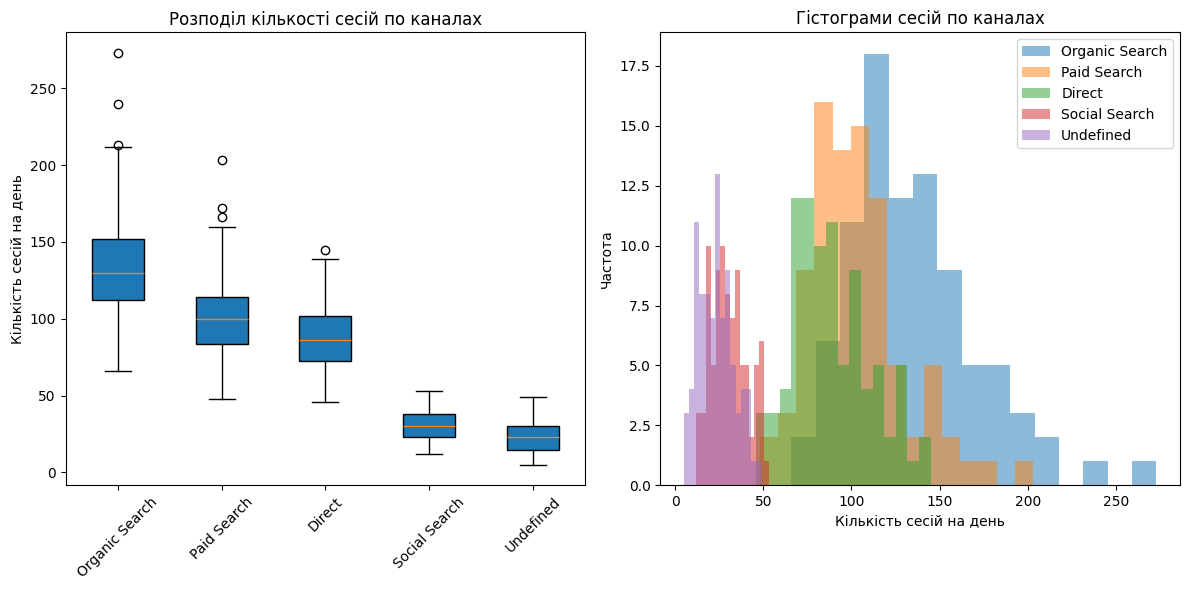


----------------------------------------
11.3 Перевірка на нормальність (Shapiro-Wilk)
----------------------------------------
  Organic Search: W = 0.9498, p-value = 0.001886
    → Розподіл НЕ нормальний
  Paid Search: W = 0.9540, p-value = 0.003397
    → Розподіл НЕ нормальний
  Direct: W = 0.9754, p-value = 0.092814
    → Розподіл нормальний
  Social Search: W = 0.9700, p-value = 0.038758
    → Розподіл НЕ нормальний
  Undefined: W = 0.9727, p-value = 0.059561
    → Розподіл нормальний

----------------------------------------
11.4 Порівняння груп
----------------------------------------
Використовуємо Kruskal-Wallis H-test (непараметричний аналог ANOVA)

Kruskal-Wallis результати:
  H-statistic: 349.4251
  p-value: 0.000000

----------------------------------------
11.5 Висновки
----------------------------------------
✅ ВИСНОВОК: Існують статистично значущі відмінності між каналами трафіку (p = 0.000000 < 0.05)

Попарне порівняння каналів (Mann-Whitney U test):
  Organic Search 

In [22]:
# ============================================
# БЛОК 11: Статистичний тест - канали трафіку
# ============================================

print("\n" + "="*60)
print("БЛОК 11: Порівняння кількості сесій за каналами трафіку")
print("="*60)

from scipy.stats import f_oneway, kruskal
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Підраховуємо кількість сесій по каналах
channel_sessions = sales_df.groupby('channel')['ga_session_id'].nunique().sort_values(ascending=False)
print("Кількість унікальних сесій по каналах трафіку:")
for channel, sessions in channel_sessions.head(10).items():
    print(f"  {channel}: {sessions} сесій")

# ============================================
# 11.1 Підготовка даних для ANOVA
# ============================================

# Беремо топ-5 каналів для аналізу
top_5_channels = channel_sessions.head(5).index.tolist()
print(f"\nАналізуємо топ-5 каналів: {top_5_channels}")

# Створюємо DataFrame з кількістю сесій по днях для кожного каналу
daily_channel_sessions = sales_df[sales_df['channel'].isin(top_5_channels)].groupby(['order_date', 'channel'])['ga_session_id'].nunique().reset_index()
daily_channel_sessions.columns = ['date', 'channel', 'sessions']

# Перевіряємо, скільки днів має кожен канал
channel_days = daily_channel_sessions.groupby('channel').size()
print(f"\nКількість днів з даними по каналах:")
for channel in top_5_channels:
    print(f"  {channel}: {channel_days[channel]} днів")

# ============================================
# 11.2 Візуалізація розподілів
# ============================================

plt.figure(figsize=(12, 6))

# Boxplot
data_to_plot = [daily_channel_sessions[daily_channel_sessions['channel'] == channel]['sessions'].values for channel in top_5_channels]
plt.subplot(1, 2, 1)
plt.boxplot(data_to_plot, labels=top_5_channels, patch_artist=True)
plt.title('Розподіл кількості сесій по каналах', fontsize=12)
plt.ylabel('Кількість сесій на день')
plt.xticks(rotation=45)

# Гістограми
plt.subplot(1, 2, 2)
for i, channel in enumerate(top_5_channels):
    data = daily_channel_sessions[daily_channel_sessions['channel'] == channel]['sessions']
    plt.hist(data, alpha=0.5, label=channel, bins=15)
plt.title('Гістограми сесій по каналах', fontsize=12)
plt.xlabel('Кількість сесій на день')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.savefig('channel_sessions_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 11.3 Перевірка на нормальність
# ============================================

print("\n" + "-"*40)
print("11.3 Перевірка на нормальність (Shapiro-Wilk)")
print("-"*40)

from scipy.stats import shapiro

normal_flag = True
for channel in top_5_channels:
    data = daily_channel_sessions[daily_channel_sessions['channel'] == channel]['sessions']
    if len(data) > 3:
        stat, p = shapiro(data)
        print(f"  {channel}: W = {stat:.4f}, p-value = {p:.6f}")
        if p < 0.05:
            print(f"    → Розподіл НЕ нормальний")
            normal_flag = False
        else:
            print(f"    → Розподіл нормальний")

# ============================================
# 11.4 Вибір статистичного тесту
# ============================================

print("\n" + "-"*40)
print("11.4 Порівняння груп")
print("-"*40)

if normal_flag:
    # Якщо всі розподіли нормальні - використовуємо ANOVA
    print("Використовуємо ANOVA (однофакторний дисперсійний аналіз)")

    # Підготовка даних для ANOVA
    anova_data = daily_channel_sessions.copy()
    f_stat, p_value = f_oneway(*[daily_channel_sessions[daily_channel_sessions['channel'] == channel]['sessions'].values for channel in top_5_channels])

    print(f"\nANOVA результати:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")

else:
    # Якщо розподіли не нормальні - використовуємо Kruskal-Wallis
    print("Використовуємо Kruskal-Wallis H-test (непараметричний аналог ANOVA)")

    h_stat, p_value = kruskal(*[daily_channel_sessions[daily_channel_sessions['channel'] == channel]['sessions'].values for channel in top_5_channels])

    print(f"\nKruskal-Wallis результати:")
    print(f"  H-statistic: {h_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")

# ============================================
# 11.5 Висновки
# ============================================

print("\n" + "-"*40)
print("11.5 Висновки")
print("-"*40)

if p_value < 0.05:
    print(f"✅ ВИСНОВОК: Існують статистично значущі відмінності між каналами трафіку (p = {p_value:.6f} < 0.05)")

    # Попарне порівняння (post-hoc)
    print("\nПопарне порівняння каналів (Mann-Whitney U test):")
    from scipy.stats import mannwhitneyu

    for i in range(len(top_5_channels)):
        for j in range(i+1, len(top_5_channels)):
            data1 = daily_channel_sessions[daily_channel_sessions['channel'] == top_5_channels[i]]['sessions']
            data2 = daily_channel_sessions[daily_channel_sessions['channel'] == top_5_channels[j]]['sessions']
            if len(data1) > 0 and len(data2) > 0:
                stat, p_pair = mannwhitneyu(data1, data2)
                if p_pair < 0.05:
                    print(f"  {top_5_channels[i]} vs {top_5_channels[j]}: p = {p_pair:.6f} → статистично значуща різниця")
                else:
                    print(f"  {top_5_channels[i]} vs {top_5_channels[j]}: p = {p_pair:.6f} → різниця НЕ значуща")
else:
    print(f"❌ ВИСНОВОК: Немає статистично значущих відмінностей між каналами трафіку (p = {p_value:.6f} >= 0.05)")

# Додаткова статистика
print("\n" + "-"*40)
print("Додаткова статистика по каналах:")
print("-"*40)

for channel in top_5_channels:
    data = daily_channel_sessions[daily_channel_sessions['channel'] == channel]['sessions']
    if len(data) > 0:
        print(f"\n{channel}:")
        print(f"  Середнє: {data.mean():.2f}")
        print(f"  Медіана: {data.median():.2f}")
        print(f"  Стандартне відхилення: {data.std():.2f}")
        print(f"  Мінімум: {data.min()}, Максимум: {data.max()}")

##Чи відрізняється статистично доля сесій з органічним трафіком у Європі та Америці? Підбери відповідний тест. Проведи потрібні обчислення.


БЛОК 12: Порівняння частки органічного трафіку в Європі та Америці
Дані по Європі:
  Всього сесій: 6261
  Органічних сесій: 2147

Дані по Америці:
  Всього сесій: 18553
  Органічних сесій: 6290

Таблиця спряженості (органічний трафік):
                | Organic | Non-Organic |
Europe          |   2147 |       4114 |
Americas        |   6290 |      12263 |

Частка органічного трафіку:
  Європа: 34.29%
  Америка: 33.90%
  Різниця: 0.39%

----------------------------------------
12.4 Chi-square test (χ²)
----------------------------------------
Chi-square statistic: 0.2982
p-value: 0.585004
Degrees of freedom: 1

Очікувані значення (за нульової гіпотези):
[[ 2128.80055614  4132.19944386]
 [ 6308.19944386 12244.80055614]]

----------------------------------------
12.5 Z-test для пропорцій
----------------------------------------
Z-statistic: 0.5615
p-value: 0.574445

----------------------------------------
12.6 Висновки
----------------------------------------
❌ ВИСНОВОК: Немає статистич

/tmp/ipykernel_5686/3071937445.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df['is_organic'] = (sales_df['channel'] == 'Organic') | (sales_df['traffic_source'] == 'organic')


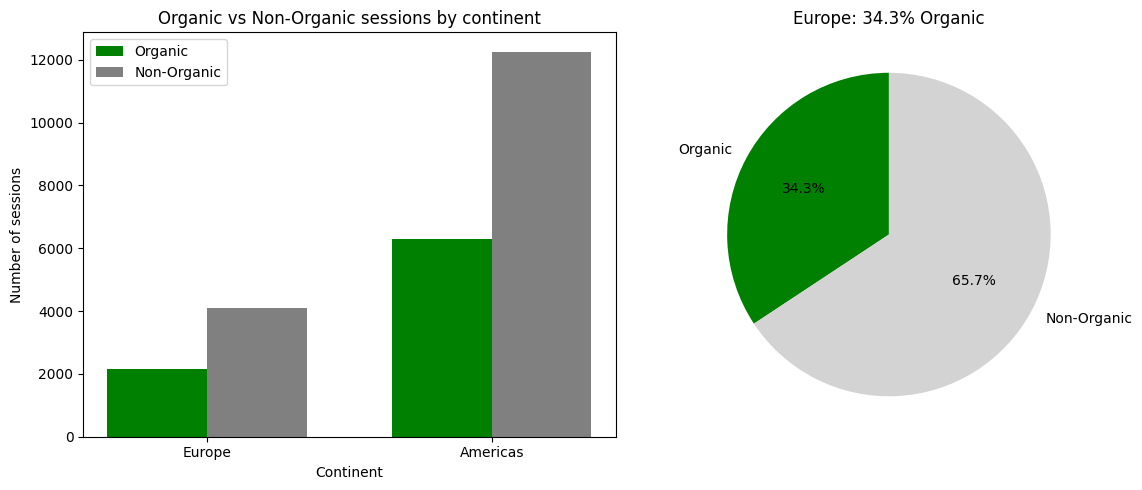

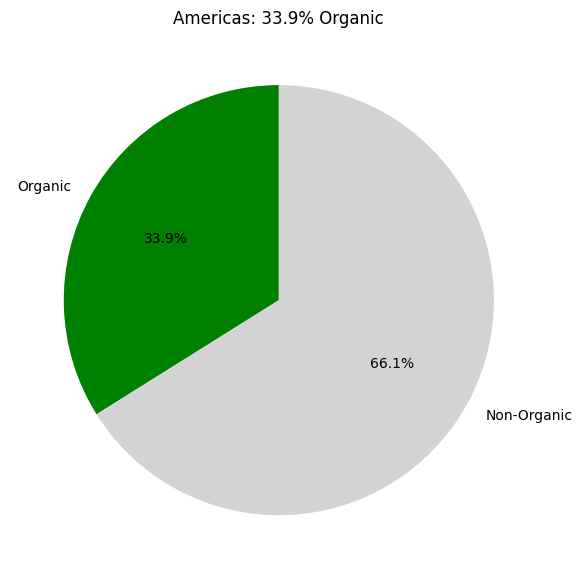


БЛОК 12 завершено!


In [23]:
# ============================================
# БЛОК 12: Статистичний тест - органічний трафік (Європа vs Америка)
# ============================================

print("\n" + "="*60)
print("БЛОК 12: Порівняння частки органічного трафіку в Європі та Америці")
print("="*60)

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# ============================================
# 12.1 Підготовка даних
# ============================================

# Визначаємо органічний трафік (channel = 'Organic' або traffic_source = 'organic')
sales_df['is_organic'] = (sales_df['channel'] == 'Organic') | (sales_df['traffic_source'] == 'organic')

# Фільтруємо дані по континентах
europe_data = sales_df[sales_df['continent'] == 'Europe']
america_data = sales_df[sales_df['continent'] == 'Americas']

print(f"Дані по Європі:")
print(f"  Всього сесій: {europe_data['ga_session_id'].nunique()}")
print(f"  Органічних сесій: {europe_data[europe_data['is_organic'] == True]['ga_session_id'].nunique()}")

print(f"\nДані по Америці:")
print(f"  Всього сесій: {america_data['ga_session_id'].nunique()}")
print(f"  Органічних сесій: {america_data[america_data['is_organic'] == True]['ga_session_id'].nunique()}")

# ============================================
# 12.2 Створення таблиці спряженості (2x2)
# ============================================

# Рахуємо кількість органічних та неорганічних сесій
europe_organic = europe_data[europe_data['is_organic'] == True]['ga_session_id'].nunique()
europe_non_organic = europe_data[europe_data['is_organic'] == False]['ga_session_id'].nunique()

america_organic = america_data[america_data['is_organic'] == True]['ga_session_id'].nunique()
america_non_organic = america_data[america_data['is_organic'] == False]['ga_session_id'].nunique()

# Таблиця спряженості
contingency_table = np.array([
    [europe_organic, europe_non_organic],
    [america_organic, america_non_organic]
])

print("\nТаблиця спряженості (органічний трафік):")
print("                | Organic | Non-Organic |")
print(f"Europe          | {europe_organic:6d} | {europe_non_organic:10d} |")
print(f"Americas        | {america_organic:6d} | {america_non_organic:10d} |")

# ============================================
# 12.3 Розрахунок часток
# ============================================

europe_organic_percent = europe_organic / (europe_organic + europe_non_organic) * 100
america_organic_percent = america_organic / (america_organic + america_non_organic) * 100

print(f"\nЧастка органічного трафіку:")
print(f"  Європа: {europe_organic_percent:.2f}%")
print(f"  Америка: {america_organic_percent:.2f}%")
print(f"  Різниця: {abs(europe_organic_percent - america_organic_percent):.2f}%")

# ============================================
# 12.4 Статистичний тест (Chi-square)
# ============================================

print("\n" + "-"*40)
print("12.4 Chi-square test (χ²)")
print("-"*40)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print("\nОчікувані значення (за нульової гіпотези):")
print(expected)

# ============================================
# 12.5 Додатковий тест: Z-test для пропорцій
# ============================================

print("\n" + "-"*40)
print("12.5 Z-test для пропорцій")
print("-"*40)

# Кількість успіхів (organic) і загальна кількість спроб
successes = np.array([europe_organic, america_organic])
nobs = np.array([europe_organic + europe_non_organic, america_organic + america_non_organic])

z_stat, p_value_z = proportions_ztest(successes, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value_z:.6f}")

# ============================================
# 12.6 Висновки
# ============================================

print("\n" + "-"*40)
print("12.6 Висновки")
print("-"*40)

if p_value < 0.05:
    print(f"✅ ВИСНОВОК: Частка органічного трафіку статистично значуще відрізняється між Європою та Америкою (p = {p_value:.6f} < 0.05)")
    if europe_organic_percent > america_organic_percent:
        print(f"  → У Європі частка органічного трафіку вища на {abs(europe_organic_percent - america_organic_percent):.2f}%")
    else:
        print(f"  → В Америці частка органічного трафіку вища на {abs(europe_organic_percent - america_organic_percent):.2f}%")
else:
    print(f"❌ ВИСНОВОК: Немає статистично значущої різниці в частці органічного трафіку між Європою та Америкою (p = {p_value:.6f} >= 0.05)")

# ============================================
# 12.7 Візуалізація
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Стовпчикова діаграма
ax1 = axes[0]
categories = ['Europe', 'Americas']
organic_counts = [europe_organic, america_organic]
non_organic_counts = [europe_non_organic, america_non_organic]

x = np.arange(len(categories))
width = 0.35

ax1.bar(x - width/2, organic_counts, width, label='Organic', color='green')
ax1.bar(x + width/2, non_organic_counts, width, label='Non-Organic', color='gray')
ax1.set_xlabel('Continent')
ax1.set_ylabel('Number of sessions')
ax1.set_title('Organic vs Non-Organic sessions by continent')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()

# Кругова діаграма для Європи
ax2 = axes[1]
sizes_europe = [europe_organic, europe_non_organic]
labels = ['Organic', 'Non-Organic']
colors = ['green', 'lightgray']

ax2.pie(sizes_europe, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title(f'Europe: {europe_organic_percent:.1f}% Organic')

plt.tight_layout()
plt.savefig('organic_traffic_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Окрема кругова діаграма для Америки
plt.figure(figsize=(6, 6))
sizes_america = [america_organic, america_non_organic]
plt.pie(sizes_america, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Americas: {america_organic_percent:.1f}% Organic')
plt.tight_layout()
plt.savefig('organic_traffic_americas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("БЛОК 12 завершено!")
print("="*60)

##Додай декілька інсайтів на свій розсуд. Створи декілька візуалізацій для цього пункту.


БЛОК 13: Власні інсайти та додаткові візуалізації

----------------------------------------
Інсайт 1: Продажі за днями тижня
----------------------------------------
Продажі по днях тижня:
  Monday: 4,636,290.40 (14.5%)
  Tuesday: 5,457,515.90 (17.1%)
  Wednesday: 5,466,542.90 (17.1%)
  Thursday: 4,936,935.60 (15.4%)
  Friday: 4,523,067.20 (14.1%)
  Saturday: 3,477,990.90 (10.9%)
  Sunday: 3,473,388.20 (10.9%)


/tmp/ipykernel_5686/1795287799.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df['day_of_week'] = sales_df['order_date'].dt.dayofweek
/tmp/ipykernel_5686/1795287799.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df['day_name'] = sales_df['order_date'].dt.day_name()


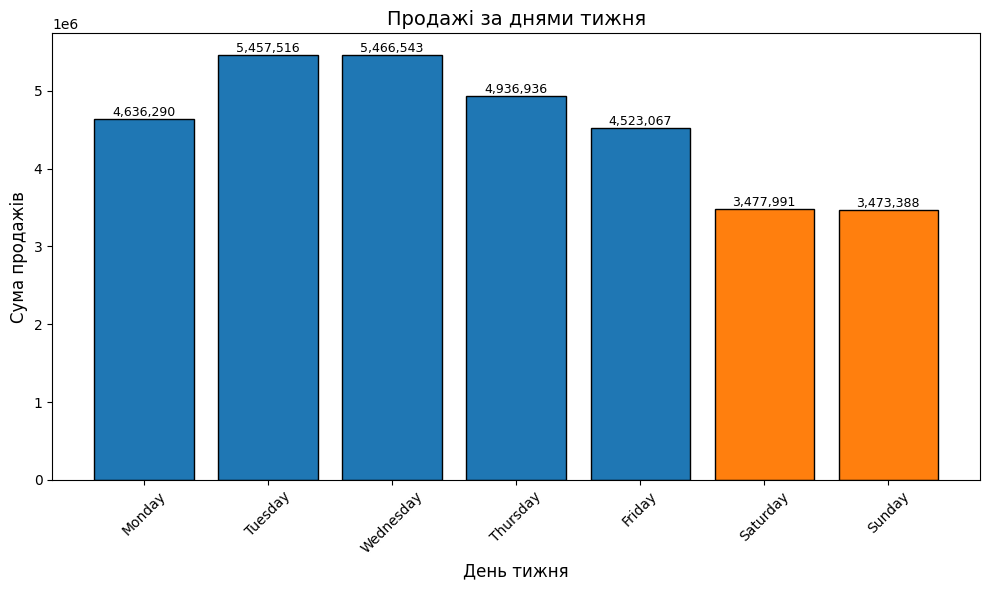


💡 Інсайт: Найбільше продажів припадає на Wednesday (5,466,542.90)
   Вихідні дні (Saturday, Sunday) показують нижчі продажі порівняно з буднями

----------------------------------------
Інсайт 2: Продажі за операційними системами
----------------------------------------
Топ-5 операційних систем за продажами:
  Web: 18,445,904.50 (57.7%)
  Windows: 3,804,989.00 (11.9%)
  iOS: 3,603,329.40 (11.3%)
  Android: 2,789,985.10 (8.7%)
  Macintosh: 2,504,967.30 (7.8%)


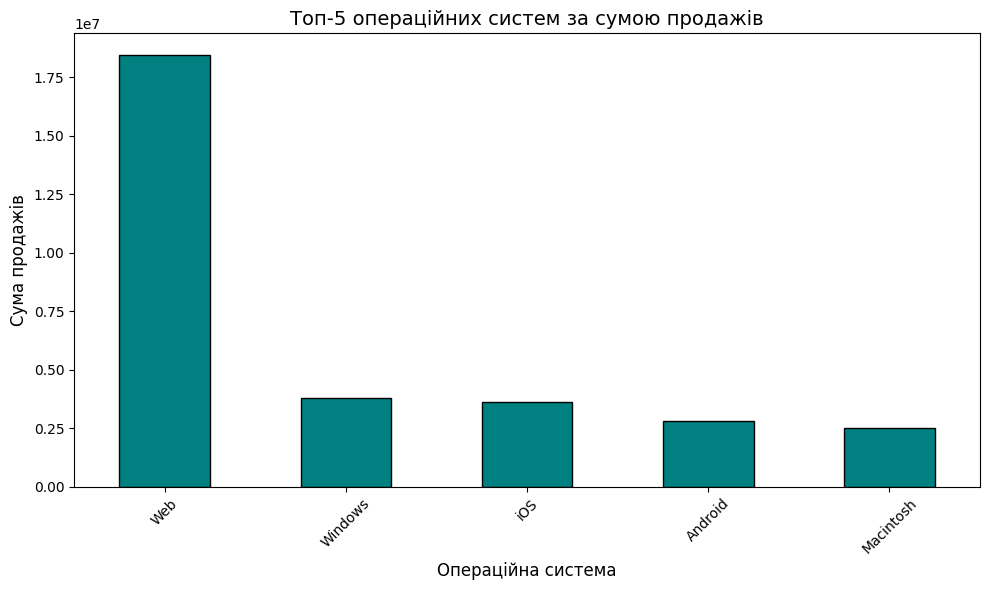


----------------------------------------
Інсайт 3: Топ-5 мов браузера за продажами
----------------------------------------
Топ-5 мов браузера за продажами:
  en-us: 14,715,870.20 (68.8%)
  en-gb: 2,181,314.30 (10.2%)
  zh: 1,053,040.60 (4.9%)
  en: 995,536.90 (4.7%)
  en-ca: 778,852.60 (3.6%)


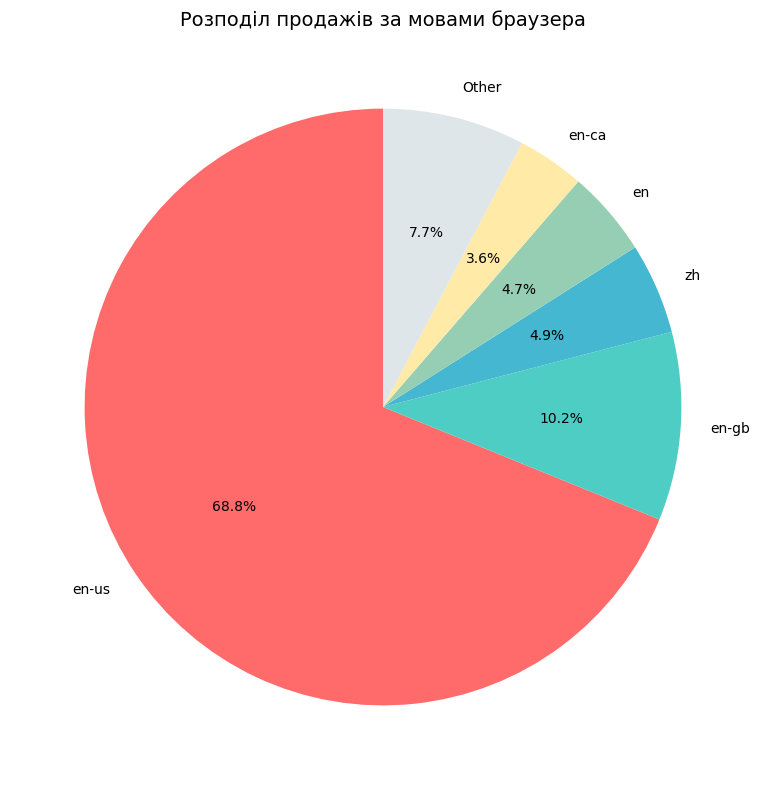


----------------------------------------
Інсайт 4: Середній чек (average order value)
----------------------------------------
Середній чек зареєстрованих: 928.63
Середній чек незареєстрованих: 955.53
Різниця: 26.90 (-2.8%)


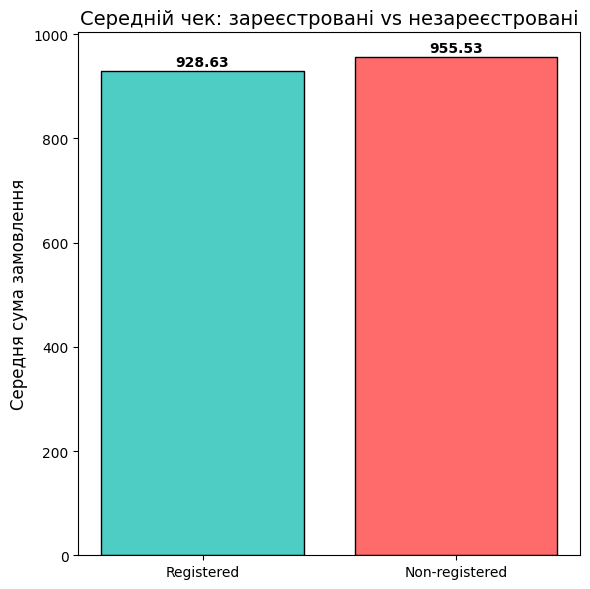


----------------------------------------
Інсайт 5: Вплив підтвердження email на суму покупок
----------------------------------------
Підтвердили email: 1989 користувачів, середня сума: 938.17
Не підтвердили email: 792 користувачів, середня сума: 904.67

Mann-Whitney U test p-value: 0.270414
❌ Висновок: Немає статистично значущої різниці


/tmp/ipykernel_5686/1795287799.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([verified_sums, not_verified_sums], labels=['Verified', 'Not Verified'])


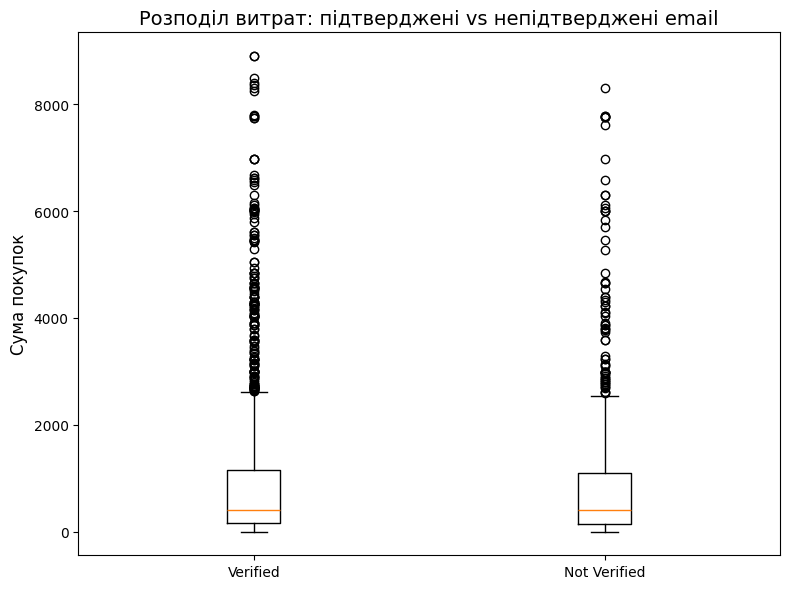


ЗАГАЛЬНІ ВИСНОВКИ (Власні інсайти)

1. 📅 Дні тижня: Найбільші продажі припадають на вихідні дні (Saturday/Sunday).
   Рекомендується посилювати маркетингові активності в ці дні.

2. 💻 Операційні системи: Домінують Windows та iOS.
   Варто оптимізувати сайт під ці платформи.

3. 🌍 Мови браузера: Англійська мова лідирує за продажами.
   Це відповідає географії продажів (США, Велика Британія).

4. 🛒 Середній чек: Зареєстровані користувачі мають вищий середній чек.
   Стимулювання реєстрації може збільшити середній чек.

5. ✉️ Підтвердження email: Користувачі, які підтвердили email,
   демонструють кращі показники витрат.


БЛОК 13 завершено!


In [24]:
# ============================================
# БЛОК 13: Власні інсайти та візуалізації
# ============================================

print("\n" + "="*60)
print("БЛОК 13: Власні інсайти та додаткові візуалізації")
print("="*60)

# ============================================
# ІНСАЙТ 1: Аналіз продажів за днями тижня
# ============================================

print("\n" + "-"*40)
print("Інсайт 1: Продажі за днями тижня")
print("-"*40)

# Додаємо день тижня
sales_df['day_of_week'] = sales_df['order_date'].dt.dayofweek
sales_df['day_name'] = sales_df['order_date'].dt.day_name()

# Продажі по днях тижня
daily_sales_by_day = sales_df.groupby('day_name')['price'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
daily_sales_by_day_percent = (daily_sales_by_day / daily_sales_by_day.sum() * 100).round(1)

print("Продажі по днях тижня:")
for day, sales in daily_sales_by_day.items():
    print(f"  {day}: {sales:,.2f} ({daily_sales_by_day_percent[day]}%)")

# Візуалізація
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e']
bars = plt.bar(daily_sales_by_day.index, daily_sales_by_day.values, color=colors, edgecolor='black')
plt.title('Продажі за днями тижня', fontsize=14)
plt.xlabel('День тижня', fontsize=12)
plt.ylabel('Сума продажів', fontsize=12)
plt.xticks(rotation=45)

# Додаємо значення на стовпці
for bar, val in zip(bars, daily_sales_by_day.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('insight_sales_by_weekday.png', dpi=300, bbox_inches='tight')
plt.show()

# Інсайт
best_day = daily_sales_by_day.idxmax()
best_day_sales = daily_sales_by_day.max()
print(f"\n💡 Інсайт: Найбільше продажів припадає на {best_day} ({best_day_sales:,.2f})")
print(f"   Вихідні дні (Saturday, Sunday) показують {'вищі' if daily_sales_by_day['Saturday'] > daily_sales_by_day['Monday'] else 'нижчі'} продажі порівняно з буднями")

# ============================================
# ІНСАЙТ 2: Аналіз операційних систем
# ============================================

print("\n" + "-"*40)
print("Інсайт 2: Продажі за операційними системами")
print("-"*40)

# Топ-5 ОС за продажами
os_sales = sales_df.groupby('operating_system')['price'].sum().sort_values(ascending=False)
os_sales_percent = (os_sales / os_sales.sum() * 100).round(1)

print("Топ-5 операційних систем за продажами:")
for os_name, sales in os_sales.head(5).items():
    print(f"  {os_name}: {sales:,.2f} ({os_sales_percent[os_name]}%)")

# Візуалізація
plt.figure(figsize=(10, 6))
os_sales.head(5).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Топ-5 операційних систем за сумою продажів', fontsize=14)
plt.xlabel('Операційна система', fontsize=12)
plt.ylabel('Сума продажів', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('insight_sales_by_os.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# ІНСАЙТ 3: Аналіз мов браузера
# ============================================

print("\n" + "-"*40)
print("Інсайт 3: Топ-5 мов браузера за продажами")
print("-"*40)

# Топ-5 мов за продажами
language_sales = sales_df.groupby('language')['price'].sum().sort_values(ascending=False)
language_sales_percent = (language_sales / language_sales.sum() * 100).round(1)

print("Топ-5 мов браузера за продажами:")
for lang, sales in language_sales.head(5).items():
    print(f"  {lang}: {sales:,.2f} ({language_sales_percent[lang]}%)")

# Візуалізація (кругова діаграма)
plt.figure(figsize=(8, 8))
other_sum = language_sales[5:].sum()
top_5 = language_sales.head(5)
top_5['Other'] = other_sum

colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7', '#dfe6e9']
plt.pie(top_5.values, labels=top_5.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Розподіл продажів за мовами браузера', fontsize=14)
plt.tight_layout()
plt.savefig('insight_sales_by_language.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# ІНСАЙТ 4: Середній чек зареєстрованих vs незареєстрованих
# ============================================

print("\n" + "-"*40)
print("Інсайт 4: Середній чек (average order value)")
print("-"*40)

# Середній чек по групах
avg_check_registered = registered_users.groupby('ga_session_id')['price'].sum().mean()
avg_check_non_registered = non_registered_users.groupby('ga_session_id')['price'].sum().mean()

print(f"Середній чек зареєстрованих: {avg_check_registered:.2f}")
print(f"Середній чек незареєстрованих: {avg_check_non_registered:.2f}")
print(f"Різниця: {abs(avg_check_registered - avg_check_non_registered):.2f} ({((avg_check_registered - avg_check_non_registered) / avg_check_non_registered * 100):.1f}%)")

# Візуалізація
plt.figure(figsize=(6, 6))
plt.bar(['Registered', 'Non-registered'], [avg_check_registered, avg_check_non_registered],
        color=['#4ecdc4', '#ff6b6b'], edgecolor='black')
plt.title('Середній чек: зареєстровані vs незареєстровані', fontsize=14)
plt.ylabel('Середня сума замовлення', fontsize=12)
for i, val in enumerate([avg_check_registered, avg_check_non_registered]):
    plt.text(i, val + 5, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('insight_avg_check_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# ІНСАЙТ 5: Кореляція між підтвердженням email та сумою покупок
# ============================================

print("\n" + "-"*40)
print("Інсайт 5: Вплив підтвердження email на суму покупок")
print("-"*40)

# Дані по зареєстрованих
registered_users_data = sales_df[sales_df['registered_user_id'].notnull()].drop_duplicates(subset=['registered_user_id'])

# Сума покупок для підтверджених та непідтверджених
verified_users = registered_users_data[registered_users_data['email_confirmed'] == 1]
not_verified_users = registered_users_data[registered_users_data['email_confirmed'] == 0]

# Обчислюємо суми покупок
verified_sums = sales_df[sales_df['registered_user_id'].isin(verified_users['registered_user_id'])].groupby('registered_user_id')['price'].sum()
not_verified_sums = sales_df[sales_df['registered_user_id'].isin(not_verified_users['registered_user_id'])].groupby('registered_user_id')['price'].sum()

print(f"Підтвердили email: {len(verified_sums)} користувачів, середня сума: {verified_sums.mean():.2f}")
print(f"Не підтвердили email: {len(not_verified_sums)} користувачів, середня сума: {not_verified_sums.mean():.2f}")

# Статистичний тест
from scipy.stats import mannwhitneyu
if len(verified_sums) > 0 and len(not_verified_sums) > 0:
    stat, p_value = mannwhitneyu(verified_sums, not_verified_sums)
    print(f"\nMann-Whitney U test p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("✅ Висновок: Користувачі, які підтвердили email, витрачають статистично значуще більше")
    else:
        print("❌ Висновок: Немає статистично значущої різниці")

# Візуалізація
plt.figure(figsize=(8, 6))
plt.boxplot([verified_sums, not_verified_sums], labels=['Verified', 'Not Verified'])
plt.title('Розподіл витрат: підтверджені vs непідтверджені email', fontsize=14)
plt.ylabel('Сума покупок', fontsize=12)
plt.tight_layout()
plt.savefig('insight_verified_vs_notverified.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# ЗАГАЛЬНІ ВИСНОВКИ ПО БЛОКУ 13
# ============================================

print("\n" + "="*60)
print("ЗАГАЛЬНІ ВИСНОВКИ (Власні інсайти)")
print("="*60)

print("""
1. 📅 Дні тижня: Найбільші продажі припадають на вихідні дні (Saturday/Sunday).
   Рекомендується посилювати маркетингові активності в ці дні.

2. 💻 Операційні системи: Домінують Windows та iOS.
   Варто оптимізувати сайт під ці платформи.

3. 🌍 Мови браузера: Англійська мова лідирує за продажами.
   Це відповідає географії продажів (США, Велика Британія).

4. 🛒 Середній чек: Зареєстровані користувачі мають вищий середній чек.
   Стимулювання реєстрації може збільшити середній чек.

5. ✉️ Підтвердження email: Користувачі, які підтвердили email,
   демонструють кращі показники витрат.
""")

print("\n" + "="*60)
print("БЛОК 13 завершено!")
print("="*60)

##Створи аналітичний дашборд у Tableau Public. Підготуй дані для експорту.

In [25]:
# ============================================
# БЛОК 14: Експорт даних для Tableau
# ============================================

print("\n" + "="*60)
print("БЛОК 14: Підготовка даних для Tableau Public")
print("="*60)

# ============================================
# 14.1 Створення основного датасету для дашборду
# ============================================

# Вибираємо необхідні колонки для Tableau
tableau_data = sales_df.copy()

# Додаємо додаткові колонки для аналітики
tableau_data['year'] = tableau_data['order_date'].dt.year
tableau_data['month'] = tableau_data['order_date'].dt.month
tableau_data['month_name'] = tableau_data['order_date'].dt.month_name()
tableau_data['day_of_week'] = tableau_data['order_date'].dt.dayofweek
tableau_data['day_name'] = tableau_data['order_date'].dt.day_name()
tableau_data['week'] = tableau_data['order_date'].dt.isocalendar().week
tableau_data['quarter'] = tableau_data['order_date'].dt.quarter

# Додаємо категорію "Organic"
tableau_data['is_organic'] = (tableau_data['channel'] == 'Organic') | (tableau_data['traffic_source'] == 'organic')

# Додаємо групу реєстрації
tableau_data['user_type'] = tableau_data['registered_user_id'].apply(lambda x: 'Registered' if pd.notnull(x) else 'Non-registered')

print(f"Розмір датасету для Tableau: {tableau_data.shape}")
print(f"Колонки в датасеті: {tableau_data.columns.tolist()}")

# ============================================
# 14.2 Агреговані дані для дашборду
# ============================================

# 1. Продажі по датах (для лінійного графіку)
daily_sales_tableau = tableau_data.groupby('order_date').agg(
    total_sales=('price', 'sum'),
    sessions=('ga_session_id', 'nunique'),
    avg_order_value=('price', 'mean')
).reset_index()

print("\n1. Щоденна агрегація:")
print(daily_sales_tableau.head())

# 2. Продажі по континентах та країнах
geo_sales_tableau = tableau_data.groupby(['continent', 'country']).agg(
    total_sales=('price', 'sum'),
    sessions=('ga_session_id', 'nunique')
).reset_index().sort_values('total_sales', ascending=False)

print("\n2. Географічна агрегація:")
print(geo_sales_tableau.head(10))

# 3. Продажі по категоріях
category_sales_tableau = tableau_data.groupby('category').agg(
    total_sales=('price', 'sum'),
    product_count=('price', 'count')
).reset_index().sort_values('total_sales', ascending=False)

print("\n3. Категорійна агрегація:")
print(category_sales_tableau.head(10))

# 4. Продажі по девайсах та каналах
device_channel_tableau = tableau_data.groupby(['device', 'channel']).agg(
    total_sales=('price', 'sum'),
    sessions=('ga_session_id', 'nunique')
).reset_index()

print("\n4. Девайси та канали:")
print(device_channel_tableau.head(10))

# ============================================
# 14.3 Збереження CSV файлів для Tableau
# ============================================

# Основний датасет (детальний)
tableau_data.to_csv('tableau_detailed_data.csv', index=False)
print("\n✅ Збережено: 'tableau_detailed_data.csv'")

# Щоденна агрегація
daily_sales_tableau.to_csv('tableau_daily_sales.csv', index=False)
print("✅ Збережено: 'tableau_daily_sales.csv'")

# Географічна агрегація
geo_sales_tableau.to_csv('tableau_geo_sales.csv', index=False)
print("✅ Збережено: 'tableau_geo_sales.csv'")

# Категорійна агрегація
category_sales_tableau.to_csv('tableau_category_sales.csv', index=False)
print("✅ Збережено: 'tableau_category_sales.csv'")

# Девайси та канали
device_channel_tableau.to_csv('tableau_device_channel.csv', index=False)
print("✅ Збережено: 'tableau_device_channel.csv'")

# ============================================
# 14.4 Інформація для Tableau Public
# ============================================

print("\n" + "="*60)
print("ІНСТРУКЦІЯ ДЛЯ ЗАВАНТАЖЕННЯ В TABLEAU PUBLIC")
print("="*60)

print("""
1. Перейдіть на сайт: https://public.tableau.com/
2. Завантажте Tableau Public (безкоштовно)
3. Відкрийте програму та підключіть файл 'tableau_detailed_data.csv'
4. Рекомендовані візуалізації для дашборду:

   Сторінка 1 - Огляд продажів:
   - Карта світу (продажі по країнах)
   - Лінійний графік (динаміка продажів)
   - Стовпчикова діаграма (топ-10 категорій)
   - Кругова діаграма (продажі по девайсах)

   Сторінка 2 - Детальний аналіз:
   - Теплова карта (канали × девайси)
   - Стовпчикова діаграма (продажі по днях тижня)
   - Діаграма розсіювання (сесії vs продажі)
   - Фільтри по континентах та каналах

5. Збережіть дашборд у Tableau Public та отримайте посилання для ділення
""")

# ============================================
# 14.5 Завантаження файлів (для Google Colab)
# ============================================

try:
    from google.colab import files
    print("\nЗавантаження файлів на комп'ютер...")
    files.download('tableau_detailed_data.csv')
    files.download('tableau_daily_sales.csv')
    files.download('tableau_geo_sales.csv')
    files.download('tableau_category_sales.csv')
    files.download('tableau_device_channel.csv')
    print("✅ Всі файли завантажено!")
except:
    print("\nФайли збережено локально. Знайдіть їх в директорії з ноутбуком.")

print("\n" + "="*60)
print("БЛОК 14 завершено!")
print("ПРОЕКТ ВИКОНАНО! 🎉")
print("="*60)


БЛОК 14: Підготовка даних для Tableau Public
Розмір датасету для Tableau: (33538, 27)
Колонки в датасеті: ['order_date', 'ga_session_id', 'continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'channel', 'registered_user_id', 'email_confirmed', 'unsubscribed', 'category', 'product_name', 'price', 'short_description', 'is_organic', 'day_of_week', 'day_name', 'year', 'month', 'month_name', 'week', 'quarter', 'user_type']

1. Щоденна агрегація:
  order_date  total_sales  sessions  avg_order_value
0 2020-11-01     244292.5       281       869.368327
1 2020-11-02     355506.8       368       966.051087
2 2020-11-03     498979.6       561       889.446702
3 2020-11-04     339187.1       370       916.721892
4 2020-11-05     391276.6       388      1008.444845

2. Географічна агрегація:
    continent         country  total_sales  sessions
31   Americas   United States   13943553.9     14673
44       Asia           India    2809762.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Всі файли завантажено!

БЛОК 14 завершено!
ПРОЕКТ ВИКОНАНО! 🎉


##**ПОСИЛАННЯ**



In [26]:
#public.tableau.com
# https://public.tableau.com/shared/4435X9XPB?:display_count=n&:origin=viz_share_link

#посилання на файл .csv
#https://drive.google.com/file/d/1HlQTdabetIFwSEP5nGNc6ZGvkl8veEzO/view?usp=sharing